In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment, PatternFill

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------- paths
import os as _os
# Project root. Override with HEADWAY_BASE_DIR, as in the other notebooks.
BASE   = _os.environ.get("HEADWAY_BASE_DIR", r"D:\Headway")
DATA   = os.path.join(BASE, "data3.xlsx")
TABLES = os.path.join(BASE, "Tables")
GRAPHS = os.path.join(BASE, "Graphics")
os.makedirs(TABLES, exist_ok=True); os.makedirs(GRAPHS, exist_ok=True)

# ---------------------------------------------------------------- config
RNG_SEED  = 20260724
N_BOOT    = 500          # parametric-bootstrap replicates for KS / AD p-values
DAIC_KEEP = 10.0         # retention window
ALPHA     = 0.05

# ---------------------------------------------------------------- candidate families
# mode "floc0": location fixed at 0 (support [0, inf))
# mode "free" : pearson3 only - its loc parameter is the MEAN, not a threshold
DISTS = {
    "gengamma":    ("Generalized gamma", stats.gengamma,    "floc0"),
    "weibull_min": ("Weibull",           stats.weibull_min, "floc0"),
    "gamma":       ("Gamma",             stats.gamma,       "floc0"),
    "fisk":        ("Log-logistic",      stats.fisk,        "floc0"),
    "lognorm":     ("Log-normal",        stats.lognorm,     "floc0"),
    "invgauss":    ("Inverse Gaussian",  stats.invgauss,    "floc0"),
    "rayleigh":    ("Rayleigh",          stats.rayleigh,    "floc0"),
    "expon":       ("Exponential",       stats.expon,       "floc0"),
    "pearson3":    ("Pearson type III",  stats.pearson3,    "free"),
}
DIST_ORDER = list(DISTS.keys())

# ---------------------------------------------------------------- fitting engine
def fit_params(key, x):
    _, d, mode = DISTS[key]
    return tuple(np.asarray(d.fit(x) if mode == "free" else d.fit(x, floc=0.0), float))

def n_free(key, par):
    return len(par) if DISTS[key][2] == "free" else len(par) - 1

def gof_stats(d, x, par):
    """KS D, Anderson-Darling A2, Cramer-von Mises W2 against the fitted CDF."""
    n = len(x); xs = np.sort(x)
    F = np.clip(d.cdf(xs, *par), 1e-12, 1 - 1e-12)
    i = np.arange(1, n + 1)
    D  = max(np.max(i / n - F), np.max(F - (i - 1) / n))
    A2 = -n - np.sum((2 * i - 1) * (np.log(F) + np.log(1 - F[::-1]))) / n
    W2 = 1.0 / (12 * n) + np.sum((F - (2 * i - 1) / (2 * n)) ** 2)
    return float(D), float(A2), float(W2)

def fit_one(key, x, n_boot=N_BOOT, seed=RNG_SEED):
    label, d, _ = DISTS[key]
    n = len(x)
    par = fit_params(key, x)
    ll  = float(np.sum(d.logpdf(x, *par)))
    if not np.isfinite(ll):
        return None
    k    = n_free(key, par)
    aic  = 2 * k - 2 * ll
    aicc = aic + (2 * k * (k + 1) / (n - k - 1)) if n - k - 1 > 0 else np.nan
    bic  = k * np.log(n) - 2 * ll
    D, A2, W2 = gof_stats(d, x, par)
    ks_asym = float(stats.kstest(x, d.name, args=par).pvalue)

    # Lilliefors-type parametric bootstrap: refit each replicate, so the null
    # distribution of D / A2 accounts for parameter estimation
    pD = pA = np.nan
    if n_boot:
        rng = np.random.default_rng(seed + (abs(hash(key)) % 10**6))
        cD = cA = ok = 0
        for _ in range(n_boot):
            try:
                y = d.rvs(*par, size=n, random_state=rng)
                y = y[np.isfinite(y) & (y > 0)]
                if len(y) < max(20, int(0.9 * n)):
                    continue
                pb = fit_params(key, y)
                Db, Ab, _ = gof_stats(d, y, pb)
            except Exception:
                continue
            ok += 1; cD += (Db >= D); cA += (Ab >= A2)
        if ok:
            pD = (1 + cD) / (1 + ok); pA = (1 + cA) / (1 + ok)

    return dict(dist=key, dist_label=label, n=n, k=k, params=par,
                logLik=ll, AIC=aic, AICc=aicc, BIC=bic,
                KS_D=D, KS_p_asym=ks_asym, KS_p_boot=pD,
                AD_A2=A2, AD_p_boot=pA, CvM_W2=W2)

def fit_group(x, label, n_boot=N_BOOT):
    rows = []
    for key in DIST_ORDER:
        try:
            r = fit_one(key, np.asarray(x, float), n_boot=n_boot)
        except Exception:
            r = None
        if r is not None:
            r["group"] = label; rows.append(r)
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out["dAIC"] = out["AIC"] - out["AIC"].min()
    w = np.exp(-out["dAIC"] / 2.0); out["AIC_w"] = w / w.sum()
    out["dBIC"] = out["BIC"] - out["BIC"].min()
    out["accepted_KS"] = out["KS_p_boot"] >= ALPHA
    out["accepted"]    = (out["KS_p_boot"] >= ALPHA) & (out["AD_p_boot"] >= ALPHA)
    out["retained_dAIC10"] = out["dAIC"] <= DAIC_KEEP
    out = out.sort_values("AIC").reset_index(drop=True)
    out["rank_AIC"] = np.arange(1, len(out) + 1)
    return out

# ---------------------------------------------------------------- plot style (TRB)
for _f in ["Times New Roman", "Nimbus Roman", "DejaVu Serif"]:
    if any(_f.lower() in ff.name.lower() for ff in mpl.font_manager.fontManager.ttflist):
        SERIF = _f; break
else:
    SERIF = "serif"
mpl.rcParams.update({
    "font.family": "serif", "font.serif": [SERIF], "font.size": 9,
    "axes.titlesize": 9.5, "axes.labelsize": 9, "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5, "legend.fontsize": 8, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110, "savefig.dpi": 600, "savefig.bbox": "tight",
    "pdf.fonttype": 42, "ps.fonttype": 42,
})
CLR = {"gengamma":"#1b3b6f","weibull_min":"#c1121f","gamma":"#2a9d8f","fisk":"#e76f51",
       "lognorm":"#7209b7","invgauss":"#f4a261","rayleigh":"#606c38","expon":"#8d99ae",
       "pearson3":"#d62828"}
LS  = {"gengamma":"-","weibull_min":"--","gamma":"-.","fisk":":",
       "lognorm":(0,(3,1,1,1)),"invgauss":(0,(5,2)),"rayleigh":(0,(1,1)),
       "expon":(0,(4,1,1,1,1,1)),"pearson3":(0,(6,2,1,2))}

def savefig(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(GRAPHS, f"{name}.{ext}"))
    print("  saved:", name, "(.png / .pdf)")

print("Cell 1 OK | serif =", SERIF, "| N_BOOT =", N_BOOT)

Cell 1 OK | serif = Times New Roman | N_BOOT = 500


In [2]:
df = pd.read_excel(DATA, sheet_name=0)
df.columns = [str(c).strip() for c in df.columns]
TH, FLOW = "Time_Headway", "Flow_pcu/hr/m"
df = df[np.isfinite(df[TH]) & np.isfinite(df[FLOW])].copy()

# ---- flow regimes: pooled tertiles of width-normalised flow
q1, q2 = df[FLOW].quantile([1/3, 2/3])
REG_LABELS = ["Low", "Moderate", "High"]
df["Flow_regime"] = pd.Categorical(
    pd.cut(df[FLOW], [-np.inf, q1, q2, np.inf], labels=REG_LABELS),
    categories=REG_LABELS, ordered=True)

# ---- analysis groups
GROUPS = {"All": df[TH].values}
for t in ["PR", "BTW"]:
    GROUPS[t] = df.loc[df["V_Target"] == t, TH].values
for r in REG_LABELS:
    GROUPS[f"All | {r}"] = df.loc[df["Flow_regime"] == r, TH].values
for t in ["PR", "BTW"]:
    for r in REG_LABELS:
        GROUPS[f"{t} | {r}"] = df.loc[(df["V_Target"] == t) &
                                      (df["Flow_regime"] == r), TH].values

def desc(x):
    x = np.asarray(x, float)
    return dict(n=len(x), mean=x.mean(), sd=x.std(ddof=1), CV=x.std(ddof=1)/x.mean(),
                min=x.min(), p25=np.percentile(x,25), median=np.median(x),
                p75=np.percentile(x,75), max=x.max(),
                skew=float(stats.skew(x)), ex_kurt=float(stats.kurtosis(x)),
                Shapiro_p=float(stats.shapiro(x).pvalue))

DESC = pd.DataFrame([dict(Group=g, **desc(x)) for g, x in GROUPS.items()])

REG_DEF = pd.DataFrame({
    "Regime": REG_LABELS,
    "Lower_bound_PCU_h_m": [df[FLOW].min(), q1, q2],
    "Upper_bound_PCU_h_m": [q1, q2, df[FLOW].max()],
    "Mean_flow": [df.loc[df["Flow_regime"]==r, FLOW].mean() for r in REG_LABELS],
    "n": [int((df["Flow_regime"]==r).sum()) for r in REG_LABELS],
    "n_PR": [int(((df["Flow_regime"]==r)&(df["V_Target"]=="PR")).sum()) for r in REG_LABELS],
    "n_BTW":[int(((df["Flow_regime"]==r)&(df["V_Target"]=="BTW")).sum()) for r in REG_LABELS],
    "n_Tikatuli":[int(((df["Flow_regime"]==r)&(df["Site"]=="Tikatuli")).sum()) for r in REG_LABELS],
    "n_Shahjahanpur":[int(((df["Flow_regime"]==r)&(df["Site"]=="Shahjahanpur")).sum()) for r in REG_LABELS],
})

print("N =", len(df), "| tertile cut-points: %.2f , %.2f PCU/h/m" % (q1, q2), "\n")
print(REG_DEF.round(2).to_string(index=False), "\n")
print(DESC.round(3).to_string(index=False))

N = 898 | tertile cut-points: 438.60 , 550.00 PCU/h/m 

  Regime  Lower_bound_PCU_h_m  Upper_bound_PCU_h_m  Mean_flow   n  n_PR  n_BTW  n_Tikatuli  n_Shahjahanpur
     Low               197.37               438.60     363.28 300    77    223         209              91
Moderate               438.60               550.00     494.09 298    73    225         207              91
    High               550.00               922.22     618.59 300    79    221         214              86 

         Group   n  mean    sd    CV   min   p25  median   p75   max   skew  ex_kurt  Shapiro_p
           All 898 2.227 0.988 0.444 0.533 1.433   2.100 2.933 4.967  0.478   -0.465      0.000
            PR 229 2.866 1.009 0.352 0.533 2.100   3.000 3.600 4.967 -0.040   -0.754      0.013
           BTW 669 2.009 0.881 0.439 0.533 1.300   1.900 2.533 4.967  0.583   -0.166      0.000
     All | Low 300 2.157 1.003 0.465 0.533 1.392   2.017 2.742 4.967  0.544   -0.324      0.000
All | Moderate 298 2.257 1.005 0.4

In [3]:
t0 = time.time()
FITS = []
for i, (g, x) in enumerate(GROUPS.items(), 1):
    ts = time.time()
    FITS.append(fit_group(x, g))
    print(f"[{i:2d}/{len(GROUPS)}] {g:16s} n={len(x):4d}  ({time.time()-ts:5.1f} s)")
FIT_ALL = pd.concat(FITS, ignore_index=True)
FIT_ALL["params_str"] = FIT_ALL["params"].apply(lambda p: ", ".join(f"{v:.4f}" for v in p))
print(f"\nTotal fitting time: {time.time()-t0:.1f} s\n")

print("=== BEST-FITTING FAMILY PER GROUP ===")
print(FIT_ALL[FIT_ALL.rank_AIC == 1][
    ["group","dist_label","n","k","AIC","AIC_w","KS_D","KS_p_asym","KS_p_boot",
     "AD_A2","AD_p_boot","accepted_KS","accepted","params_str"]
].round(4).to_string(index=False))

print("\n=== RETAINED SET (dAIC <= 10), in AIC order ===")
for g in GROUPS:
    sub = FIT_ALL[(FIT_ALL.group == g) & FIT_ALL.retained_dAIC10].sort_values("rank_AIC")
    print(f"{g:16s} -> " + ";  ".join(
        f"{r.dist_label} ({r.dAIC:.1f})" for r in sub.itertuples()))

[ 1/12] All              n= 898  ( 18.2 s)
[ 2/12] PR               n= 229  ( 17.0 s)
[ 3/12] BTW              n= 669  ( 17.8 s)
[ 4/12] All | Low        n= 300  ( 13.9 s)
[ 5/12] All | Moderate   n= 298  ( 15.0 s)
[ 6/12] All | High       n= 300  ( 15.1 s)
[ 7/12] PR | Low         n=  77  ( 16.2 s)
[ 8/12] PR | Moderate    n=  73  ( 17.8 s)
[ 9/12] PR | High        n=  79  ( 16.3 s)
[10/12] BTW | Low        n= 223  ( 14.0 s)
[11/12] BTW | Moderate   n= 225  ( 19.9 s)
[12/12] BTW | High       n= 221  ( 18.7 s)

Total fitting time: 200.0 s

=== BEST-FITTING FAMILY PER GROUP ===
         group        dist_label   n  k       AIC  AIC_w   KS_D  KS_p_asym  KS_p_boot  AD_A2  AD_p_boot  accepted_KS  accepted                     params_str
           All Generalized gamma 898  3 2452.0851 0.7353 0.0406     0.1012     0.0020 1.5424     0.0020        False     False 2.1910, 1.5408, 0.0000, 1.4085
            PR Generalized gamma 229  3  651.4628 0.5595 0.0619     0.3313     0.0060 0.6539     0.0

In [4]:
def two_sample_tbl(sub, by, labels):
    out = []
    for i in range(len(labels)):
        for j in range(i+1, len(labels)):
            a = sub.loc[sub[by]==labels[i], TH].values
            b = sub.loc[sub[by]==labels[j], TH].values
            if len(a) < 5 or len(b) < 5: continue
            ks = stats.ks_2samp(a, b)
            mw = stats.mannwhitneyu(a, b, alternative="two-sided")
            out.append(dict(Comparison=f"{labels[i]} vs {labels[j]}", n1=len(a), n2=len(b),
                            KS_D=ks.statistic, KS_p=ks.pvalue, MWU_p=mw.pvalue,
                            Cliffs_delta=2*mw.statistic/(len(a)*len(b)) - 1))
    return pd.DataFrame(out)

CMP = []
for t in ["All", "PR", "BTW"]:
    sub = df if t == "All" else df[df["V_Target"] == t]
    tt = two_sample_tbl(sub, "Flow_regime", REG_LABELS); tt.insert(0, "Stratum", t); CMP.append(tt)
tt = two_sample_tbl(df, "V_Target", ["PR", "BTW"]); tt.insert(0, "Stratum", "Target type"); CMP.append(tt)
CMP = pd.concat(CMP, ignore_index=True)

COLS = ["group","dist","dist_label","n","k","params_str","logLik","AIC","AICc","dAIC","AIC_w",
        "BIC","dBIC","KS_D","KS_p_asym","KS_p_boot","AD_A2","AD_p_boot","CvM_W2",
        "accepted_KS","accepted","retained_dAIC10","rank_AIC"]
OUT_ALL  = FIT_ALL[COLS].copy()
OUT_KEEP = OUT_ALL[OUT_ALL.retained_dAIC10].copy()
OUT_BEST = OUT_ALL[OUT_ALL.rank_AIC == 1].copy()

def ms_table(groups):
    t = OUT_KEEP[OUT_KEEP.group.isin(groups)].sort_values(["group","rank_AIC"]).copy()
    t["Fit"] = np.where(t.rank_AIC == 1, "Best", "Competing")
    return t[["group","Fit","dist_label","n","k","params_str","logLik","AIC","dAIC","AIC_w",
              "KS_D","KS_p_boot","AD_A2","AD_p_boot","accepted"]]

MS_OVERALL = ms_table(["All","PR","BTW"])
MS_REGIME  = ms_table([f"{t} | {r}" for t in ["All","PR","BTW"] for r in REG_LABELS])

xlsx = os.path.join(TABLES, "T1_Baseline_Headway_Distributions.xlsx")
with pd.ExcelWriter(xlsx, engine="openpyxl") as xw:
    REG_DEF.round(4).to_excel(xw,   sheet_name="S1_Regime_definition",   index=False)
    DESC.round(4).to_excel(xw,      sheet_name="S2_Group_descriptives",  index=False)
    OUT_ALL.round(6).to_excel(xw,   sheet_name="S3_Fits_all",            index=False)
    OUT_KEEP.round(6).to_excel(xw,  sheet_name="S4_Retained_dAIC10",     index=False)
    OUT_BEST.round(6).to_excel(xw,  sheet_name="S5_Best_per_group",      index=False)
    MS_OVERALL.round(4).to_excel(xw,sheet_name="S6_MS_overall",          index=False)
    MS_REGIME.round(4).to_excel(xw, sheet_name="S7_MS_regime",           index=False)
    CMP.round(6).to_excel(xw,       sheet_name="S8_Empirical_comparisons",index=False)

wb = load_workbook(xlsx)
hdr = Font(bold=True, color="FFFFFF"); fill = PatternFill("solid", fgColor="1B3B6F")
for ws in wb.worksheets:
    ws.freeze_panes = "A2"; ws.row_dimensions[1].height = 30
    for c in ws[1]:
        c.font = hdr; c.fill = fill
        c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    for col in ws.columns:
        L = max((len(str(c.value)) for c in col if c.value is not None), default=8)
        ws.column_dimensions[col[0].column_letter].width = min(max(10, L + 2), 34)
wb.save(xlsx)
print("wrote:", xlsx)
print(MS_OVERALL.round(3).to_string(index=False))

wrote: D:\Headway\Tables\T1_Baseline_Headway_Distributions.xlsx
group       Fit        dist_label   n  k                     params_str    logLik      AIC  dAIC  AIC_w  KS_D  KS_p_boot  AD_A2  AD_p_boot  accepted
  All      Best Generalized gamma 898  3 2.1910, 1.5408, 0.0000, 1.4085 -1223.043 2452.085 0.000  0.735 0.041      0.002  1.542      0.002     False
  All Competing             Gamma 898  2         4.7735, 0.0000, 0.4666 -1225.465 2454.929 2.844  0.177 0.043      0.002  1.734      0.004     False
  All Competing  Pearson type III 898  3         0.9481, 2.2274, 1.0252 -1225.391 2456.782 4.696  0.070 0.043      0.002  1.778      0.002     False
  All Competing           Weibull 898  2         2.4275, 0.0000, 2.5189 -1227.806 2459.611 7.526  0.017 0.038      0.004  2.289      0.002     False
  BTW      Best             Gamma 669  2         5.0189, 0.0000, 0.4003  -829.666 1663.332 0.000  0.452 0.029      0.204  0.758      0.052      True
  BTW Competing  Pearson type III 669  3  

  saved: F1_TopFits_PR_BTW (.png / .pdf)


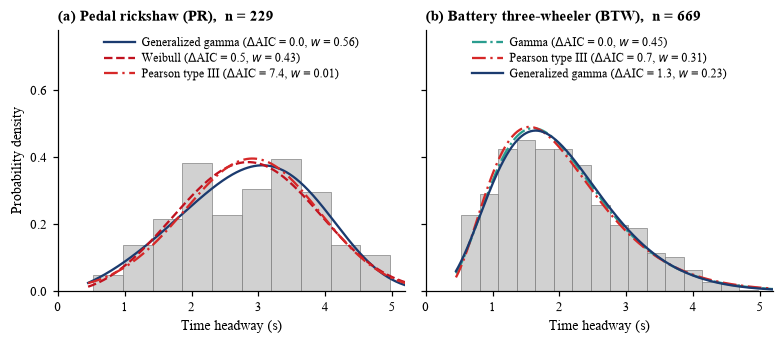

  saved: F2_PR_vs_BTW_empirical (.png / .pdf)


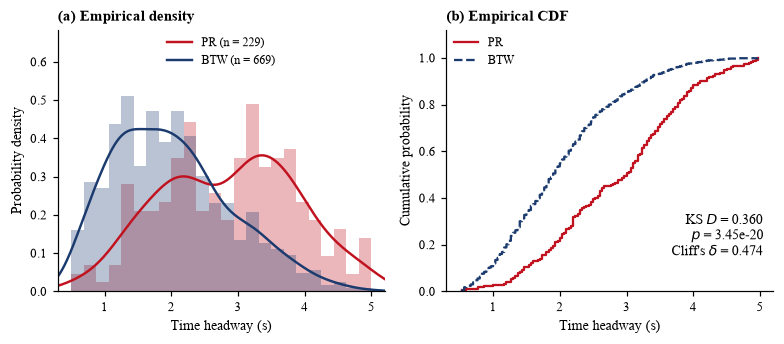

In [5]:
ABBR = {"Generalized gamma": "Gen. gamma", "Pearson type III": "Pearson III",
        "Inverse Gaussian": "Inv. Gaussian"}

def panel(ax, x, fits, top=3, title="", bins=None, short_leg=False,
          leg_loc="upper center", headroom=True):
    """Histogram + top-`top` fitted PDFs. Legend is placed in reserved headroom
    above the data, never over it."""
    x = np.asarray(x, float)
    if bins is None:
        bins = np.histogram_bin_edges(x, bins="fd")
        if len(bins) > 30: bins = np.linspace(x.min(), x.max(), 26)
    h, _ = np.histogram(x, bins=bins, density=True)
    ax.hist(x, bins=bins, density=True, color="0.82", edgecolor="0.45", lw=0.4, zorder=1)

    grid = np.linspace(max(1e-3, x.min()*0.85), x.max()*1.06, 400)
    ymax = float(h.max())
    for _, r in fits.sort_values("rank_AIC").head(top).iterrows():
        d = DISTS[r["dist"]][1]
        y = d.pdf(grid, *r["params"])
        ymax = max(ymax, float(np.nanmax(y[np.isfinite(y)])))
        nm = ABBR.get(r["dist_label"], r["dist_label"]) if short_leg else r["dist_label"]
        lab = (f"{nm} ($\\Delta$AIC = {r['dAIC']:.1f})" if short_leg
               else f"{nm} ($\\Delta$AIC = {r['dAIC']:.1f}, $w$ = {r['AIC_w']:.2f})")
        ax.plot(grid, y, color=CLR[r["dist"]], linestyle=LS[r["dist"]], lw=1.5,
                zorder=3, label=lab)

    ax.set_xlabel("Time headway (s)"); ax.set_ylabel("Probability density")
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_xlim(0, 5.2)
    if headroom:                      # reserve vertical space for the legend
        need = ymax * (1.0 + 0.15 * top + 0.14)
        ax.set_ylim(0, max(ax.get_ylim()[1], need))   # monotone: safe under sharey
    ax.yaxis.set_major_locator(MaxNLocator(5))
    ax.legend(frameon=False, loc=leg_loc,
              fontsize=7 if short_leg else 8,
              handlelength=1.9 if short_leg else 2.6,
              borderaxespad=0.2, labelspacing=0.30, handletextpad=0.5)
    return ax

# ---------------- Figure 1: top-3 fits, PR and BTW overall ----------------
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), sharey=True)
for ax, g, lab in zip(axes, ["PR", "BTW"],
                      ["(a) Pedal rickshaw (PR)", "(b) Battery three-wheeler (BTW)"]):
    panel(ax, GROUPS[g], FIT_ALL[FIT_ALL.group == g], 3, f"{lab},  n = {len(GROUPS[g])}")
axes[1].set_ylabel("")
fig.tight_layout(); savefig(fig, "F1_TopFits_PR_BTW"); plt.show()

# ---------------- Figure 2: empirical density and CDF, PR vs BTW ----------------
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))

ax = axes[0]; bins = np.linspace(0.5, 5.0, 25); ymax = 0.0
for g, c in zip(["PR", "BTW"], ["#c1121f", "#1b3b6f"]):
    h, _ = np.histogram(GROUPS[g], bins=bins, density=True)
    ax.hist(GROUPS[g], bins=bins, density=True, alpha=0.30, color=c)
    kde = stats.gaussian_kde(GROUPS[g]); gx = np.linspace(0.3, 5.2, 300)
    ax.plot(gx, kde(gx), color=c, lw=1.6, label=f"{g} (n = {len(GROUPS[g])})")
    ymax = max(ymax, float(h.max()), float(kde(gx).max()))
ax.set_xlabel("Time headway (s)"); ax.set_ylabel("Probability density")
ax.set_title("(a) Empirical density", loc="left", fontweight="bold")
ax.set_xlim(0.3, 5.2); ax.set_ylim(0, ymax * 1.34)
ax.legend(frameon=False, loc="upper center", borderaxespad=0.2)

ax = axes[1]
for g, c, ls in zip(["PR", "BTW"], ["#c1121f", "#1b3b6f"], ["-", "--"]):
    xs = np.sort(GROUPS[g])
    ax.step(xs, np.arange(1, len(xs)+1)/len(xs), where="post",
            color=c, ls=ls, lw=1.5, label=g)
ks  = stats.ks_2samp(GROUPS["PR"], GROUPS["BTW"])
mw  = stats.mannwhitneyu(GROUPS["PR"], GROUPS["BTW"])
dlt = 2*mw.statistic/(len(GROUPS["PR"])*len(GROUPS["BTW"])) - 1
ax.text(0.97, 0.30, f"KS $D$ = {ks.statistic:.3f}\n$p$ = {ks.pvalue:.3g}\n"
                    f"Cliff's $\\delta$ = {dlt:.3f}",
        transform=ax.transAxes, ha="right", va="top")
ax.set_xlabel("Time headway (s)"); ax.set_ylabel("Cumulative probability")
ax.set_title("(b) Empirical CDF", loc="left", fontweight="bold")
ax.set_xlim(0.3, 5.2); ax.set_ylim(0, 1.12)
ax.legend(frameon=False, loc="upper left", borderaxespad=0.2)

fig.tight_layout(); savefig(fig, "F2_PR_vs_BTW_empirical"); plt.show()

  saved: F3_Regime_fits (.png / .pdf)


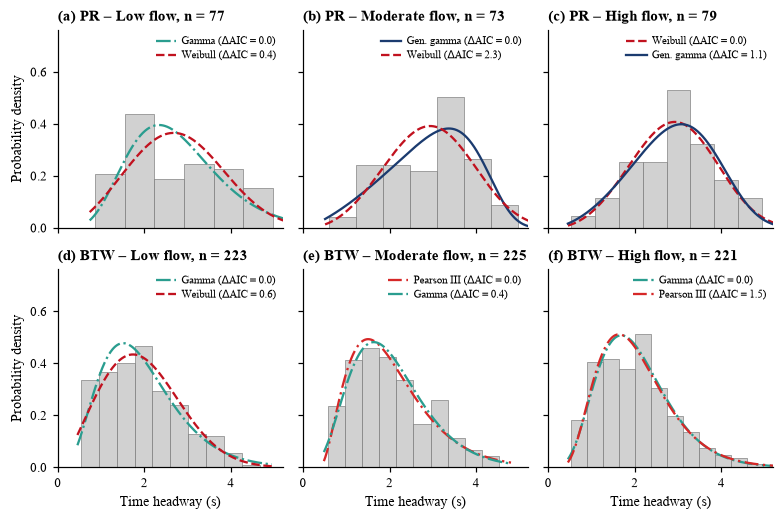

  saved: F4_PP_plots (.png / .pdf)


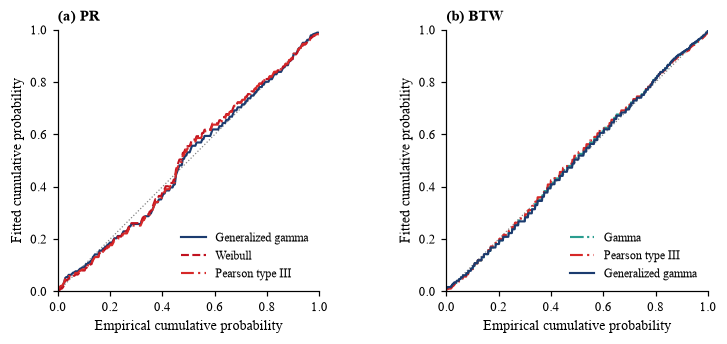


Tables -> D:\Headway\Tables
Graphics -> D:\Headway\Graphics


In [6]:
# ---- Figure 3: regime-wise fits, PR (top) and BTW (bottom)
fig, axes = plt.subplots(2, 3, figsize=(7.2, 4.8), sharex=True, sharey=True)
for i, t in enumerate(["PR", "BTW"]):
    for j, r in enumerate(REG_LABELS):
        g = f"{t} | {r}"
        panel(axes[i, j], GROUPS[g], FIT_ALL[FIT_ALL.group == g], 2,
              f"({chr(97+i*3+j)}) {t} \u2013 {r} flow, n = {len(GROUPS[g])}",
              short_leg=True, leg_loc="upper right")
        if j: axes[i, j].set_ylabel("")
        if i == 0: axes[i, j].set_xlabel("")
fig.tight_layout(); savefig(fig, "F3_Regime_fits"); plt.show()

# ---- Figure 4: P-P plots for the top-3 overall fits
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))
for ax, g, lab in zip(axes, ["PR", "BTW"], ["(a) PR", "(b) BTW"]):
    x = np.sort(GROUPS[g]); n = len(x); emp = (np.arange(1, n+1) - 0.5) / n
    ax.plot([0, 1], [0, 1], color="0.5", lw=0.8, ls=":")
    for _, r in FIT_ALL[FIT_ALL.group == g].sort_values("rank_AIC").head(3).iterrows():
        d = DISTS[r["dist"]][1]
        ax.plot(emp, d.cdf(x, *r["params"]), color=CLR[r["dist"]], ls=LS[r["dist"]],
                lw=1.4, label=r["dist_label"])
    ax.set_xlabel("Empirical cumulative probability")
    ax.set_ylabel("Fitted cumulative probability")
    ax.set_title(lab, loc="left", fontweight="bold")
    ax.legend(frameon=False, loc="lower right")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
fig.tight_layout(); savefig(fig, "F4_PP_plots"); plt.show()

print("\nTables ->", TABLES)
print("Graphics ->", GRAPHS)

In [7]:
# ---------------- shortlist carried forward from the baseline stage ----------------
SHORT = ["gengamma", "gamma", "weibull_min", "pearson3", "lognorm", "invgauss"]
DROPPED_BASE = ["fisk", "rayleigh", "expon"]      # reported as excluded, not fitted
RANK_BY   = "AICc"        # AICc: n/k < 40 for every pair (Burnham & Anderson 2002)
N_MIN     = 30            # retention threshold
N_LIMITED = 50            # below this: retained but flagged limited precision
DKEEP     = 10.0

def fit_group_keys(x, label, keys=SHORT, n_boot=N_BOOT, rank_by=RANK_BY):
    """As fit_group(), but over a chosen subset of families and ranked on AIC or AICc."""
    rows = []
    for key in keys:
        try:
            r = fit_one(key, np.asarray(x, float), n_boot=n_boot)
        except Exception:
            r = None
        if r is not None:
            r["group"] = label; rows.append(r)
    out = pd.DataFrame(rows)
    if out.empty: return out
    crit = out[rank_by].values
    out["dAIC"]  = out["AIC"]  - out["AIC"].min()
    out["dAICc"] = out["AICc"] - out["AICc"].min()
    d = crit - np.nanmin(crit)
    w = np.exp(-d / 2.0); out["AIC_w"] = w / np.nansum(w)
    out["accepted_KS"] = out["KS_p_boot"] >= ALPHA
    out["accepted"]    = (out["KS_p_boot"] >= ALPHA) & (out["AD_p_boot"] >= ALPHA)
    out["retained"]    = d <= DKEEP
    out = out.assign(_c=d).sort_values("_c").drop(columns="_c").reset_index(drop=True)
    out["rank"] = np.arange(1, len(out) + 1)
    return out

# ---------------- pair inventory ----------------
PAIR_N = df["Pair"].value_counts()
INV = pd.DataFrame({"Pair": PAIR_N.index, "n": PAIR_N.values})
INV["Target"]  = INV["Pair"].str.split("_following_").str[0]
INV["Leader"]  = INV["Pair"].str.split("_following_").str[1]
INV["pct"]     = 100 * INV["n"] / len(df)
INV["Tier"]    = np.where(INV["n"] < N_MIN, "Insufficient",
                 np.where(INV["n"] < N_LIMITED, "Limited precision", "Adequate"))
INV["Retained"] = INV["n"] >= N_MIN
INV["mean_TH"] = INV["Pair"].map(df.groupby("Pair")[TH].mean())
INV["sd_TH"]   = INV["Pair"].map(df.groupby("Pair")[TH].std())
INV["skew_TH"] = INV["Pair"].map(df.groupby("Pair")[TH].apply(lambda s: float(stats.skew(s))))
INV = INV[["Pair","Target","Leader","n","pct","mean_TH","sd_TH","skew_TH","Tier","Retained"]]
INV = INV.sort_values(["Target","n"], ascending=[True, False]).reset_index(drop=True)

KEPT_PAIRS = INV.loc[INV.Retained, "Pair"].tolist()
PAIR_DATA  = {p: df.loc[df["Pair"] == p, TH].values for p in KEPT_PAIRS}

print(INV.round(3).to_string(index=False))
print(f"\nRetained {len(KEPT_PAIRS)}/{len(INV)} pairs | "
      f"{int(INV.loc[INV.Retained,'n'].sum())}/{len(df)} events "
      f"({100*INV.loc[INV.Retained,'n'].sum()/len(df):.1f}%)")
print("Dropped:", ", ".join(f"{r.Pair} (n={r.n})" for r in INV[~INV.Retained].itertuples()))

                Pair Target Leader   n    pct  mean_TH  sd_TH  skew_TH              Tier  Retained
    BTW_following_4W    BTW     4W 250 27.840    2.284  0.852    0.385          Adequate      True
 BTW_following_MT_3W    BTW  MT_3W 186 20.713    1.863  0.863    0.925          Adequate      True
BTW_following_NMT_3W    BTW NMT_3W 119 13.252    1.915  0.897    0.572          Adequate      True
 BTW_following_MT_2W    BTW  MT_2W  73  8.129    1.765  0.810    0.743          Adequate      True
BTW_following_NMT_2W    BTW NMT_2W  41  4.566    1.697  0.807    0.746 Limited precision      True
  PR_following_MT_3W     PR  MT_3W 104 11.581    2.857  0.919   -0.072          Adequate      True
 PR_following_NMT_3W     PR NMT_3W  49  5.457    2.708  0.998   -0.092 Limited precision      True
     PR_following_4W     PR     4W  43  4.788    2.978  1.082   -0.160 Limited precision      True
  PR_following_MT_2W     PR  MT_2W  23  2.561    3.126  1.070    0.115      Insufficient     False
 PR_follow

In [8]:
t0 = time.time()

# ---------------- 1. parent (class-level) reference models ----------------
PARENT = {}
for cls in ["PR", "BTW"]:
    xcls = GROUPS[cls]
    for key in SHORT:
        par = fit_params(key, xcls)
        PARENT[(cls, key)] = dict(params=par,
                                  logLik=float(np.sum(DISTS[key][1].logpdf(xcls, *par))))
print("parent models fitted for PR and BTW\n")

# ---------------- 2. pair-specific fits ----------------
PFITS = []
for i, p in enumerate(KEPT_PAIRS, 1):
    ts = time.time()
    r = fit_group_keys(PAIR_DATA[p], p)
    PFITS.append(r)
    print(f"[{i}/{len(KEPT_PAIRS)}] {p:22s} n={len(PAIR_DATA[p]):4d}  "
          f"best={r.iloc[0].dist_label:18s} ({time.time()-ts:5.1f} s)")
PAIR_FITS = pd.concat(PFITS, ignore_index=True)
PAIR_FITS["Target"] = PAIR_FITS["group"].str.split("_following_").str[0]
PAIR_FITS["Leader"] = PAIR_FITS["group"].str.split("_following_").str[1]
PAIR_FITS["params_str"] = PAIR_FITS["params"].apply(lambda q: ", ".join(f"{v:.4f}" for v in q))

# ---------------- 3. pair-specific vs parent-class model ----------------
rows = []
for _, r in PAIR_FITS.iterrows():
    key, cls = r["dist"], r["Target"]
    d = DISTS[key][1]
    x = PAIR_DATA[r["group"]]; n = len(x)
    ppar = PARENT[(cls, key)]["params"]
    ll_par = float(np.sum(d.logpdf(x, *ppar)))          # parent params held fixed -> k = 0
    aic_par = -2 * ll_par
    lr = 2 * (r["logLik"] - ll_par)
    rows.append(dict(
        group=r["group"], Target=cls, Leader=r["Leader"], dist=key,
        dist_label=r["dist_label"], n=n, k=r["k"],
        logLik_pair=r["logLik"], AIC_pair=r["AIC"], AICc_pair=r["AICc"],
        logLik_parent=ll_par, AIC_parent=aic_par,
        gain_AIC=aic_par - r["AIC"],                    # >0 : pair-specific preferred
        LR_chi2=lr, LR_df=r["k"],
        LR_p=float(stats.chi2.sf(lr, r["k"])) if lr > 0 else 1.0,
        KS_D_parent=float(stats.kstest(x, d.name, args=ppar).statistic),
        KS_p_parent=float(stats.kstest(x, d.name, args=ppar).pvalue),
        KS_D_pair=r["KS_D"], KS_p_pair=r["KS_p_boot"],
        improves=(aic_par - r["AIC"]) >= 2.0))
VS_PARENT = pd.DataFrame(rows)

# ---------------- 4. does pair identity matter at all? (class-level pooling test) ----------------
rows = []
for cls in ["PR", "BTW"]:
    ps = [p for p in KEPT_PAIRS if p.startswith(cls + "_")]
    xu = np.concatenate([PAIR_DATA[p] for p in ps])
    for key in SHORT:
        d = DISTS[key][1]
        par_pool = fit_params(key, xu)                   # refit on retained pairs only
        ll_pool = float(np.sum(d.logpdf(xu, *par_pool)))
        ll_full = float(sum(PAIR_FITS.loc[(PAIR_FITS.group == p) &
                                          (PAIR_FITS.dist == key), "logLik"].iloc[0] for p in ps))
        kk = int(PAIR_FITS.loc[PAIR_FITS.dist == key, "k"].iloc[0])
        dfree = (len(ps) - 1) * kk
        lr = 2 * (ll_full - ll_pool)
        rows.append(dict(Target=cls, n_pairs=len(ps), n=len(xu), dist_label=DISTS[key][0],
                         k=kk, logLik_pooled=ll_pool, logLik_pairwise=ll_full,
                         LR_chi2=lr, df=dfree, p=float(stats.chi2.sf(lr, dfree)),
                         AIC_pooled=2*kk-2*ll_pool,
                         AIC_pairwise=2*kk*len(ps)-2*ll_full))
POOL_LRT = pd.DataFrame(rows)
POOL_LRT["gain_AIC"] = POOL_LRT["AIC_pooled"] - POOL_LRT["AIC_pairwise"]

print(f"\nTotal: {time.time()-t0:.1f} s\n")
print("=== BEST FIT PER PAIR ===")
print(PAIR_FITS[PAIR_FITS["rank"] == 1][
    ["group","n","dist_label","k","AICc","AIC_w","KS_D","KS_p_boot","AD_A2","AD_p_boot",
     "accepted","params_str"]].round(4).to_string(index=False))

print("\n=== RETAINED SET PER PAIR (d%s <= %.0f) ===" % (RANK_BY, DKEEP))
for p in KEPT_PAIRS:
    s = PAIR_FITS[(PAIR_FITS.group == p) & PAIR_FITS.retained].sort_values("rank")
    print(f"{p:22s} -> " + ";  ".join(
        f"{r.dist_label} ({r.dAICc:.1f}{'*' if r.accepted else ''})" for r in s.itertuples()))
print("  (* = accepted on both bootstrap KS and AD)")

print("\n=== PAIR-SPECIFIC vs PARENT-CLASS MODEL (best family per pair) ===")
best_keys = PAIR_FITS[PAIR_FITS["rank"] == 1][["group","dist"]]
print(VS_PARENT.merge(best_keys, on=["group","dist"])[
    ["group","dist_label","n","gain_AIC","LR_chi2","LR_df","LR_p",
     "KS_D_parent","KS_p_parent","KS_D_pair","KS_p_pair","improves"]
].round(4).to_string(index=False))

print("\n=== POOLING TEST: pair-specific vs single class distribution ===")
print(POOL_LRT.round(4).to_string(index=False))

parent models fitted for PR and BTW

[1/8] BTW_following_4W       n= 250  best=Generalized gamma  ( 12.3 s)
[2/8] BTW_following_MT_3W    n= 186  best=Pearson type III   ( 19.2 s)
[3/8] BTW_following_NMT_3W   n= 119  best=Pearson type III   ( 16.3 s)
[4/8] BTW_following_MT_2W    n=  73  best=Pearson type III   ( 16.8 s)
[5/8] BTW_following_NMT_2W   n=  41  best=Inverse Gaussian   ( 17.3 s)
[6/8] PR_following_MT_3W     n= 104  best=Weibull            ( 12.7 s)
[7/8] PR_following_NMT_3W    n=  49  best=Weibull            ( 13.4 s)
[8/8] PR_following_4W        n=  43  best=Weibull            ( 13.8 s)

Total: 122.0 s

=== BEST FIT PER PAIR ===
               group   n        dist_label  k     AICc  AIC_w   KS_D  KS_p_boot  AD_A2  AD_p_boot  accepted                     params_str
    BTW_following_4W 250 Generalized gamma  3 623.7198 0.3978 0.0302     0.7984 0.2104     0.7824      True 2.0043, 1.9492, 0.0000, 1.7009
 BTW_following_MT_3W 186  Pearson type III  3 442.3435 0.2828 0.0375     0

In [9]:
PCOLS = ["group","Target","Leader","dist","dist_label","n","k","params_str","logLik",
         "AIC","AICc","dAIC","dAICc","AIC_w","BIC","KS_D","KS_p_asym","KS_p_boot",
         "AD_A2","AD_p_boot","CvM_W2","accepted_KS","accepted","retained","rank"]
P_ALL  = PAIR_FITS[PCOLS].copy()
P_KEEP = P_ALL[P_ALL.retained].copy()
P_BEST = P_ALL[P_ALL["rank"] == 1].copy()

MS_PAIR = P_KEEP.sort_values(["Target","n","rank"], ascending=[True, False, True])[
    ["group","n","dist_label","k","params_str","AICc","dAICc","AIC_w",
     "KS_D","KS_p_boot","AD_A2","AD_p_boot","accepted"]].copy()
MS_PAIR["Fit"] = np.where(MS_PAIR.dAICc == 0, "Best", "Competing")

SHORTLIST = pd.DataFrame({
    "Distribution": [DISTS[k][0] for k in SHORT] + [DISTS[k][0] for k in DROPPED_BASE],
    "Carried forward": ["Yes"]*len(SHORT) + ["No"]*len(DROPPED_BASE),
    "Free parameters": [3 if k in ("gengamma","pearson3") else (2 if k != "rayleigh" else 1)
                        for k in SHORT + DROPPED_BASE]})

xlsx2 = os.path.join(TABLES, "T2_Pairwise_Headway_Distributions.xlsx")
with pd.ExcelWriter(xlsx2, engine="openpyxl") as xw:
    SHORTLIST.to_excel(xw,            sheet_name="S0_Shortlist",        index=False)
    INV.round(4).to_excel(xw,         sheet_name="S1_Pair_inventory",   index=False)
    P_ALL.round(6).to_excel(xw,       sheet_name="S2_Fits_all",         index=False)
    P_KEEP.round(6).to_excel(xw,      sheet_name="S3_Retained",         index=False)
    P_BEST.round(6).to_excel(xw,      sheet_name="S4_Best_per_pair",    index=False)
    VS_PARENT.round(6).to_excel(xw,   sheet_name="S5_Pair_vs_parent",   index=False)
    POOL_LRT.round(6).to_excel(xw,    sheet_name="S6_Pooling_LRT",      index=False)
    MS_PAIR.round(4).to_excel(xw,     sheet_name="S7_MS_pairwise",      index=False)

wb = load_workbook(xlsx2)
hdr = Font(bold=True, color="FFFFFF"); fill = PatternFill("solid", fgColor="1B3B6F")
for ws in wb.worksheets:
    ws.freeze_panes = "A2"; ws.row_dimensions[1].height = 30
    for c in ws[1]:
        c.font = hdr; c.fill = fill
        c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    for col in ws.columns:
        L = max((len(str(c.value)) for c in col if c.value is not None), default=8)
        ws.column_dimensions[col[0].column_letter].width = min(max(10, L + 2), 34)
wb.save(xlsx2)
print("wrote:", xlsx2)

wrote: D:\Headway\Tables\T2_Pairwise_Headway_Distributions.xlsx


  saved: F5_Pairwise_fits (.png / .pdf)


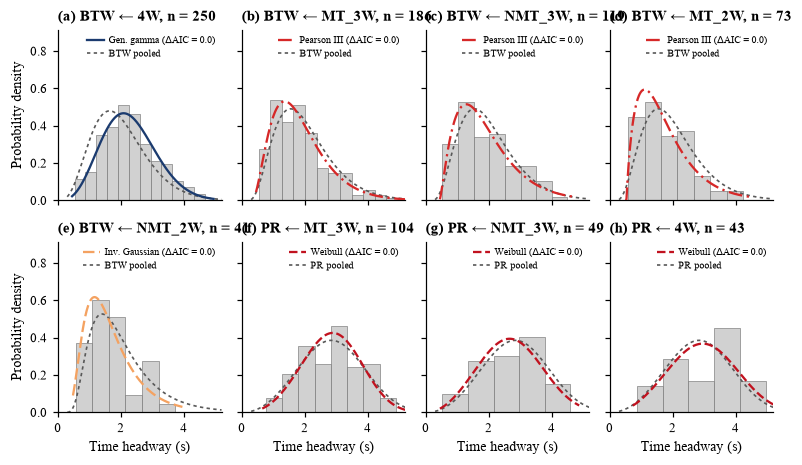

  saved: F6_Pairwise_dAICc_heatmap (.png / .pdf)


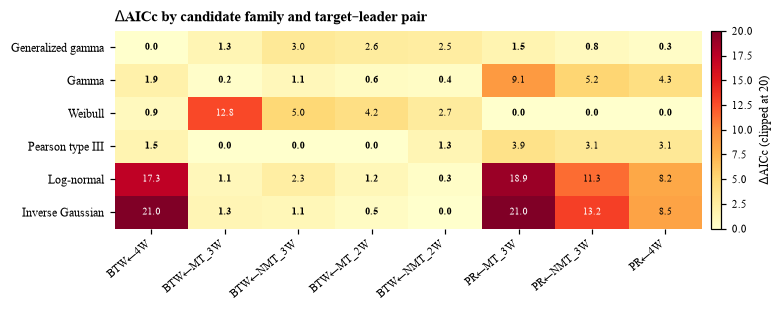


Tables -> D:\Headway\Tables 
Graphics -> D:\Headway\Graphics


In [10]:
# ---- bridge: panel() expects 'rank_AIC'/'dAIC'; pair-wise frame uses 'rank'/'dAICc'
PF_PLOT = PAIR_FITS.assign(rank_AIC=PAIR_FITS["rank"], dAIC=PAIR_FITS["dAICc"])

def _bins_of(x):
    b = np.histogram_bin_edges(x, bins="fd")
    return np.linspace(x.min(), x.max(), 26) if len(b) > 30 else b

# ---------------- Figure 5: pair-wise fits with parent-class overlay ----------------
order = INV.loc[INV.Retained].sort_values(["Target","n"], ascending=[True, False])["Pair"].tolist()
ncol = 4; nrow = int(np.ceil(len(order) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(7.2, 2.15 * nrow), sharex=True, sharey=True)
axes = np.atleast_2d(axes)
grid = np.linspace(0.3, 5.2, 400)

for idx, p in enumerate(order):
    ax = axes.ravel()[idx]
    x = PAIR_DATA[p]; cls = p.split("_following_")[0]
    fits = PF_PLOT[PF_PLOT.group == p]

    panel(ax, x, fits, 1,
          f"({chr(97+idx)}) {p.replace('_following_', ' \u2190 ')}, n = {len(x)}",
          short_leg=True, leg_loc="upper right", headroom=False)

    bk = fits.sort_values("rank_AIC").iloc[0]                    # parent overlay, same family
    d  = DISTS[bk["dist"]][1]
    y_pair   = d.pdf(grid, *bk["params"])
    y_parent = d.pdf(grid, *PARENT[(cls, bk["dist"])]["params"])
    ax.plot(grid, y_parent, color="0.35", ls=(0, (2, 2)), lw=1.1, zorder=2,
            label=f"{cls} pooled")

    h, _ = np.histogram(x, bins=_bins_of(x), density=True)
    need = 1.48 * max(float(h.max()), float(np.nanmax(y_pair)), float(np.nanmax(y_parent)))
    ax.set_ylim(0, max(ax.get_ylim()[1], need))                  # monotone: safe under sharey

    ax.legend(frameon=False, loc="upper right", fontsize=6.5,
              handlelength=1.7, labelspacing=0.28, handletextpad=0.45, borderaxespad=0.2)
    if idx % ncol: ax.set_ylabel("")
    if idx < len(order) - ncol: ax.set_xlabel("")

for j in range(len(order), nrow * ncol):
    axes.ravel()[j].axis("off")
fig.tight_layout(); savefig(fig, "F5_Pairwise_fits"); plt.show()

# ---------------- Figure 6: dAICc heat map, distributions x pairs ----------------
H = (PAIR_FITS.pivot(index="dist_label", columns="group", values="dAICc")
              .reindex([DISTS[k][0] for k in SHORT])[order])
fig, ax = plt.subplots(figsize=(7.2, 2.9))
M = H.values.astype(float)
im = ax.imshow(np.clip(M, 0, 20), cmap="YlOrRd", aspect="auto", vmin=0, vmax=20)
ax.set_xticks(range(H.shape[1]))
ax.set_xticklabels([c.replace("_following_", "\u2190") for c in H.columns],
                   rotation=40, ha="right", fontsize=7.5)
ax.set_yticks(range(H.shape[0])); ax.set_yticklabels(H.index, fontsize=8)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M[i, j]
        if np.isfinite(v):
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=6.8,
                    color="white" if v > 12 else "black",
                    fontweight="bold" if v <= 2 else "normal")
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.015)
cb.set_label("$\\Delta$AICc (clipped at 20)", fontsize=8); cb.ax.tick_params(labelsize=7.5)
ax.set_title("$\\Delta$AICc by candidate family and target\u2013leader pair",
             loc="left", fontweight="bold")
for s in ax.spines.values(): s.set_visible(False)
fig.tight_layout(); savefig(fig, "F6_Pairwise_dAICc_heatmap"); plt.show()

print("\nTables ->", TABLES, "\nGraphics ->", GRAPHS)

In [11]:
# ============================ CELL 11 : pair-wise manuscript table ============================
DCARRY     = 2.0                                   # carry-forward window (dAICc)
LEAD_ORDER = ["4W", "MT_3W", "MT_2W", "NMT_3W", "NMT_2W"]

# ---- carry-forward set: every (pair, distribution) within dAICc <= 2 of its pair leader
CARRY = PAIR_FITS[PAIR_FITS["dAICc"] <= DCARRY].copy()
CARRY["Target"] = pd.Categorical(CARRY["Target"], ["PR", "BTW"], ordered=True)
CARRY["Leader"] = pd.Categorical(CARRY["Leader"], LEAD_ORDER, ordered=True)
CARRY = CARRY.sort_values(["Target", "Leader", "dAICc"]).reset_index(drop=True)

# ---- accepted models sitting outside the window (reported as supplementary)
EXTRA = PAIR_FITS[(PAIR_FITS["dAICc"] > DCARRY) & PAIR_FITS["accepted"]].copy()
EXTRA["Target"] = pd.Categorical(EXTRA["Target"], ["PR", "BTW"], ordered=True)
EXTRA["Leader"] = pd.Categorical(EXTRA["Leader"], LEAD_ORDER, ordered=True)
EXTRA = EXTRA.sort_values(["Target", "Leader", "dAICc"]).reset_index(drop=True)

def ms_format(src, collapse=True):
    t = pd.DataFrame({
        "Target (follower)": src["Target"].astype(str),
        "Leading class":     src["Leader"].astype(str),
        "n":                 src["n"].astype(str),
        "Distribution":      src["dist_label"],
        "k":                 src["k"],
        "Parameters":        src["params_str"],
        "dAICc":             src["dAICc"].round(2),
        "w":                 src["AIC_w"].round(3),
        "KS D (p)":          src.apply(lambda r: f"{r.KS_D:.3f} ({r.KS_p_boot:.3f})", axis=1),
        "AD A2 (p)":         src.apply(lambda r: f"{r.AD_A2:.3f} ({r.AD_p_boot:.3f})", axis=1),
        "Accepted":          np.where(src["accepted"], "Yes", "No"),
    })
    if collapse:                                   # blank repeated pair labels for readability
        dup = t.duplicated(["Target (follower)", "Leading class"])
        t.loc[dup, ["Target (follower)", "Leading class", "n"]] = ""
    return t

MS_MAIN  = ms_format(CARRY)
MS_SUPP  = ms_format(EXTRA)

# ---- acceptance matrix: distributions x pairs
ACC = (PAIR_FITS.assign(cell=np.where(PAIR_FITS["accepted"], "Yes", "No"))
                .pivot(index="dist_label", columns="group", values="cell")
                .reindex([DISTS[k][0] for k in SHORT]))
ACC = ACC[[p for p in INV.loc[INV.Retained, "Pair"] if p in ACC.columns]]
ACC.columns = [c.replace("_following_", " \u2192 ") for c in ACC.columns]
ACC["Accepted in"] = (PAIR_FITS[PAIR_FITS["accepted"]]
                      .groupby("dist_label").size()
                      .reindex([DISTS[k][0] for k in SHORT]).fillna(0).astype(int)
                      .astype(str) + f" of {len(KEPT_PAIRS)}").values
ACC = ACC.reset_index().rename(columns={"dist_label": "Distribution"})

# ---- export
xlsx3 = os.path.join(TABLES, "T3_Pairwise_Manuscript_Table.xlsx")
with pd.ExcelWriter(xlsx3, engine="openpyxl") as xw:
    MS_MAIN.to_excel(xw,  sheet_name="Table_main",         index=False)
    MS_SUPP.to_excel(xw,  sheet_name="Table_supplementary", index=False)
    ACC.to_excel(xw,      sheet_name="Acceptance_matrix",   index=False)
    CARRY[["group","Target","Leader","n","dist","dist_label","k","params_str",
           "AICc","dAICc","AIC_w","KS_D","KS_p_boot","AD_A2","AD_p_boot",
           "accepted"]].round(6).to_excel(xw, sheet_name="Carry_forward_set", index=False)

wb = load_workbook(xlsx3)
hdr = Font(bold=True, color="FFFFFF"); fill = PatternFill("solid", fgColor="1B3B6F")
for ws in wb.worksheets:
    ws.freeze_panes = "A2"; ws.row_dimensions[1].height = 28
    for c in ws[1]:
        c.font = hdr; c.fill = fill
        c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    for col in ws.columns:
        L = max((len(str(c.value)) for c in col if c.value is not None), default=8)
        ws.column_dimensions[col[0].column_letter].width = min(max(10, L + 2), 34)
wb.save(xlsx3)

print(MS_MAIN.to_string(index=False))
print("\n--- accepted outside the dAICc <= 2 window ---")
print(MS_SUPP.to_string(index=False))
print("\n--- acceptance matrix ---")
print(ACC.to_string(index=False))
print(f"\ncarry-forward set: {len(CARRY)} pair-distribution combinations "
      f"across {CARRY['group'].nunique()} pairs "
      f"({int(CARRY['accepted'].sum())} accepted, {int((~CARRY['accepted']).sum())} not)")
print("wrote:", xlsx3)

Target (follower) Leading class   n      Distribution  k                      Parameters  dAICc     w      KS D (p)     AD A2 (p) Accepted
               PR            4W  43           Weibull  2          3.1565, 0.0000, 3.3365   0.00 0.453 0.143 (0.030) 0.797 (0.032)       No
                                    Generalized gamma  3  0.3096, 7.2951, 0.0000, 4.3806   0.33 0.385 0.114 (0.198) 0.467 (0.198)      Yes
               PR         MT_3W 104           Weibull  2          3.5179, 0.0000, 3.1792   0.00 0.618 0.076 (0.114) 0.441 (0.263)      Yes
                                    Generalized gamma  3  0.6478, 4.6656, 0.0000, 3.6126   1.55 0.285 0.070 (0.144) 0.375 (0.242)      Yes
               PR        NMT_3W  49           Weibull  2          3.0628, 0.0000, 3.0337   0.00 0.508 0.091 (0.353) 0.405 (0.351)      Yes
                                    Generalized gamma  3  0.3547, 6.3338, 0.0000, 3.9564   0.79 0.342 0.109 (0.118) 0.278 (0.531)      Yes
              BTW          

In [12]:
# ============================ CELL 12 : covariate screening (AFT, per carried-forward model) ============================
from scipy import optimize

CARRY_SET = CARRY.copy()                              # 26 pair x distribution models from Cell 11
LR_ALPHA  = 0.05
DAICC_IMP = 2.0                                        # per-covariate improvement threshold

# ---- candidate covariates: continuous (z-scored) and binary (0/1) ----
COVS = {
    "Target_Speed_km/hr":  "cont",
    "Leading_Speed_km/hr": "cont",
    "Speed_Difference":    "cont",
    "Flow_pcu/hr/m":       "cont",
    "Off_centeredness":    "bin",
    "Occupancy":           "bin",
    "Site":                "bin",
}
COV_LABEL = {
    "Target_Speed_km/hr": "Target speed", "Leading_Speed_km/hr": "Leader speed",
    "Speed_Difference": "Speed difference", "Flow_pcu/hr/m": "Traffic flow",
    "Off_centeredness": "Off-centeredness", "Occupancy": "Occupancy", "Site": "Site",
}

Xc = pd.DataFrame(index=df.index)
for c, t in COVS.items():
    v = df[c]
    if t == "cont":
        Xc[c] = (v - v.mean()) / v.std(ddof=1)
    elif v.dtype == bool:
        Xc[c] = v.astype(float)
    else:
        Xc[c] = (v == sorted(v.unique())[1]).astype(float)

# ---- log-linear AFT: log-scale (or PH-free location) shifted by a single covariate ----
def _n_shape(key, x):
    """Number of genuine shape parameters (fitted vector minus loc and scale)."""
    return len(fit_params(key, x)) - 2

def _aft_nll(theta, key, x, z, nsh):
    _, d, mode = DISTS[key]
    sh = theta[:nsh]
    if mode == "free":
        loc0, sc0, b = theta[nsh], theta[nsh+1], theta[nsh+2]
    else:
        loc0, sc0, b = 0.0, theta[nsh], theta[nsh+1]
    if sc0 <= 0:
        return 1e12
    eta = z * b
    try:
        lp = d.logpdf(x * np.exp(-eta), *sh, loc0, sc0) - eta      # AFT Jacobian
    except Exception:
        return 1e12
    return -lp.sum() if np.all(np.isfinite(lp)) else 1e12

def _aft_fit(key, x, z):
    _, d, mode = DISTS[key]
    base = fit_params(key, x)
    nsh  = len(base) - 2
    th0  = list(base[:nsh]) + ([base[-2]] if mode == "free" else []) + [base[-1], 0.0]
    r = optimize.minimize(lambda th: _aft_nll(th, key, x, z, nsh), th0,
                          method="Nelder-Mead",
                          options=dict(maxiter=20000, maxfev=20000, xatol=1e-6, fatol=1e-6))
    return r.x, -r.fun

def _null_loglik(key, x):
    _, d, _ = DISTS[key]
    return float(np.sum(d.logpdf(x, *fit_params(key, x))))

# ---- screen every covariate against every carried-forward model ----
rows = []
for _, cr in CARRY_SET.iterrows():
    p, key = cr["group"], cr["dist"]
    m = (df["Pair"] == p).values
    x = df.loc[m, TH].values; n = len(x)
    kb = int(cr["k"])
    ll0 = _null_loglik(key, x)
    aicc0 = 2*kb - 2*ll0 + 2*kb*(kb+1)/(n-kb-1)
    for c in COVS:
        z = Xc.loc[m, c].values
        skip = np.std(z) < 1e-9 or (COVS[c] == "bin" and
               min((z == 0).sum(), (z == 1).sum()) < 5)
        if skip:
            rows.append(dict(pair=p, dist=key, dist_label=cr["dist_label"], cov=c,
                             beta=np.nan, LR_chi2=np.nan, LR_p=np.nan, dAICc=np.nan,
                             improves=False, estimable=False)); continue
        th, ll1 = _aft_fit(key, x, z)
        k1 = kb + 1
        aicc1 = 2*k1 - 2*ll1 + 2*k1*(k1+1)/(n-k1-1)
        lr = max(2*(ll1 - ll0), 0.0)
        pv = float(stats.chi2.sf(lr, 1))
        d_aicc = aicc0 - aicc1
        rows.append(dict(pair=p, dist=key, dist_label=cr["dist_label"], cov=c,
                         beta=float(th[-1]), LR_chi2=lr, LR_p=pv, dAICc=d_aicc,
                         improves=(d_aicc >= DAICC_IMP) and (pv < LR_ALPHA),
                         estimable=True))
SCREEN = pd.DataFrame(rows)
SCREEN["Covariate"] = SCREEN["cov"].map(COV_LABEL)
SCREEN["Pair"] = SCREEN["pair"].str.replace("_following_", " \u2192 ", regex=False)

# ---- covariate ranking (the table of interest) ----
def _rank(g):
    est = g[g.estimable]
    return pd.Series({
        "Models tested":     int(len(g)),
        "Estimable":         int(len(est)),
        "n improving":       int(g["improves"].sum()),
        "% improving":       round(100 * g["improves"].sum() / max(len(est), 1), 1),
        "Median dAICc":      round(est["dAICc"].median(), 2),
        "Max dAICc":         round(est["dAICc"].max(), 2),
        "n signif (p<0.05)": int((est["LR_p"] < LR_ALPHA).sum()),
        "Median |beta|":     round(est["beta"].abs().median(), 3),
    })
RANK = (SCREEN.groupby("Covariate").apply(_rank)
        .sort_values(["n improving", "Median dAICc"], ascending=False)
        .reset_index())
RANK.insert(0, "Rank", np.arange(1, len(RANK) + 1))

# ---- per-pair dAICc matrix (covariate x pair, averaged over that pair's carried models) ----
MAT = (SCREEN[SCREEN.estimable]
       .groupby(["Covariate", "Pair"])["dAICc"].mean()
       .unstack("Pair").round(2))
MAT = MAT.reindex(RANK["Covariate"].tolist())

# ---- export ----
xlsx4 = os.path.join(TABLES, "T4_Covariate_Selection.xlsx")
with pd.ExcelWriter(xlsx4, engine="openpyxl") as xw:
    RANK.to_excel(xw,   sheet_name="Ranking",          index=False)
    MAT.to_excel(xw,    sheet_name="dAICc_matrix")
    SCREEN[["Pair","dist_label","Covariate","beta","LR_chi2","LR_p","dAICc",
            "improves","estimable"]].round(5).to_excel(
            xw, sheet_name="Full_screen", index=False)

wb = load_workbook(xlsx4)
hdr = Font(bold=True, color="FFFFFF"); fill = PatternFill("solid", fgColor="1B3B6F")
for ws in wb.worksheets:
    ws.freeze_panes = "B2"; ws.row_dimensions[1].height = 28
    for c in ws[1]:
        c.font = hdr; c.fill = fill
        c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    for col in ws.columns:
        L = max((len(str(c.value)) for c in col if c.value is not None), default=8)
        ws.column_dimensions[col[0].column_letter].width = min(max(10, L + 2), 32)
wb.save(xlsx4)

print(f"screened {SCREEN['estimable'].sum()} estimable covariate-model combinations "
      f"across {CARRY_SET['group'].nunique()} pairs x {len(COVS)} covariates\n")
print("=== COVARIATE RANKING ===")
print(RANK.to_string(index=False))
print("\n=== MEAN dAICc BY COVARIATE x PAIR ===")
print(MAT.to_string())
print("\nwrote:", xlsx4)

screened 182 estimable covariate-model combinations across 8 pairs x 7 covariates

=== COVARIATE RANKING ===
 Rank        Covariate  Models tested  Estimable  n improving  % improving  Median dAICc  Max dAICc  n signif (p<0.05)  Median |beta|
    1 Speed difference           26.0       26.0         17.0         65.4          5.98      40.51               17.0          0.162
    2     Target speed           26.0       26.0         17.0         65.4          2.83      41.84               18.0          0.117
    3             Site           26.0       26.0         10.0         38.5          0.50      12.68               10.0          0.131
    4 Off-centeredness           26.0       26.0          5.0         19.2         -0.51       4.17                6.0          0.115
    5        Occupancy           26.0       26.0          3.0         11.5         -1.54       9.21                3.0          0.070
    6     Leader speed           26.0       26.0          1.0          3.8         -1.6

In [13]:
# ============================ CELL 13 : final pair-wise AFT models (per-pair forward selection) ============================
from scipy import optimize

DAICc_IN   = 2.0        # AICc improvement required to admit a covariate (forward step)
VIF_WARN   = 5.0
VIF_FAIL   = 10.0       # any retained-covariate VIF above this -> fall back to covariate-free fit
N_BOOT_GOF = 500        # bootstrap replicates for the final KS / AD acceptance tests

# ---- standardized / coded covariate matrix ----
Xc = pd.DataFrame(index=df.index)
for c, t in COVS.items():
    v = df[c]
    if t == "cont":                 Xc[c] = (v - v.mean()) / v.std(ddof=1)
    elif v.dtype == bool:           Xc[c] = v.astype(float)
    else:                           Xc[c] = (v == sorted(v.unique())[1]).astype(float)

# ---- AFT log-likelihood machinery ----
def _fp(key, x):
    _, d, mode = DISTS[key]
    return tuple(np.asarray(d.fit(x) if mode == "free" else d.fit(x, floc=0.0), float))

def _aft_nll(theta, key, x, Z, nsh):
    _, d, mode = DISTS[key]
    sh = theta[:nsh]
    if mode == "free": loc0, sc0, b = theta[nsh], theta[nsh+1], theta[nsh+2:]
    else:              loc0, sc0, b = 0.0,        theta[nsh],   theta[nsh+1:]
    if sc0 <= 0: return 1e12
    eta = Z @ b if Z.shape[1] else np.zeros(len(x))
    try:    lp = d.logpdf(x * np.exp(-eta), *sh, loc0, sc0) - eta
    except Exception: return 1e12
    return -lp.sum() if np.all(np.isfinite(lp)) else 1e12

def _aft_fit(key, x, Z):
    base = _fp(key, x); _, d, mode = DISTS[key]; nsh = len(base) - 2
    th0 = list(base[:nsh]) + ([base[-2]] if mode == "free" else []) + [base[-1]] + [0.0]*Z.shape[1]
    r = optimize.minimize(lambda th: _aft_nll(th, key, x, Z, nsh), th0, method="Nelder-Mead",
                          options=dict(maxiter=30000, maxfev=30000, xatol=1e-7, fatol=1e-7))
    return r.x, -r.fun, nsh

def _aicc(ll, k, n): return 2*k - 2*ll + (2*k*(k+1)/(n-k-1) if n-k-1 > 0 else np.inf)

def _kb(key, x): return 3 if DISTS[key][2] == "free" else len(_fp(key, x)) - 1

def _vif_max(Z):
    if Z.shape[1] < 2: return 1.0
    out = []
    for j in range(Z.shape[1]):
        y = Z[:, j]; Xo = np.column_stack([np.ones(len(y)), np.delete(Z, j, axis=1)])
        b, *_ = np.linalg.lstsq(Xo, y, rcond=None); r = y - Xo @ b
        r2 = 1 - r.var()/y.var() if y.var() > 0 else 0.0
        out.append(1/(1-r2) if r2 < 1 else np.inf)
    return float(max(out))

def _estimable(z, kind):
    return not (np.std(z) < 1e-9 or (kind == "bin" and min((z == 0).sum(), (z == 1).sum()) < 5))

# ---- AFT residual GoF: transform to baseline scale, test against fitted null ----
def _aft_gof(key, theta, x, Z, nsh, n_boot, seed):
    _, d, mode = DISTS[key]
    sh = theta[:nsh]
    if mode == "free": loc0, sc0, b = theta[nsh], theta[nsh+1], theta[nsh+2:]
    else:              loc0, sc0, b = 0.0,        theta[nsh],   theta[nsh+1:]
    eta = Z @ b if Z.shape[1] else np.zeros(len(x))
    x0  = x * np.exp(-eta)                       # acceleration-corrected headways
    def _stats(xx):
        xs = np.sort(xx); nn = len(xs)
        F = np.clip(d.cdf(xs, *sh, loc0, sc0), 1e-12, 1-1e-12); i = np.arange(1, nn+1)
        D  = max(np.max(i/nn - F), np.max(F - (i-1)/nn))
        A2 = -nn - np.sum((2*i-1)*(np.log(F) + np.log(1-F[::-1])))/nn
        return D, A2
    D, A2 = _stats(x0)
    rng = np.random.default_rng(seed); cD = cA = ok = 0
    for _ in range(n_boot):
        try:
            y = d.rvs(*sh, loc0, sc0, size=len(x), random_state=rng)
            y = y[np.isfinite(y) & (y > 0)]
            if len(y) < max(20, int(0.9*len(x))): continue
            pb = _fp(key, y); Db, Ab = _stats2(d, y, pb)
        except Exception:
            continue
        ok += 1; cD += (Db >= D); cA += (Ab >= A2)
    pD = (1+cD)/(1+ok) if ok else np.nan
    pA = (1+cA)/(1+ok) if ok else np.nan
    return D, A2, pD, pA

def _stats2(d, xx, par):
    xs = np.sort(xx); nn = len(xs)
    F = np.clip(d.cdf(xs, *par), 1e-12, 1-1e-12); i = np.arange(1, nn+1)
    D  = max(np.max(i/nn - F), np.max(F - (i-1)/nn))
    A2 = -nn - np.sum((2*i-1)*(np.log(F) + np.log(1-F[::-1])))/nn
    return D, A2

# ---- per-pair covariate entry order = mean univariate dAICc over that pair's carried dists ----
def _entry_order(dists, idx):
    x = df.loc[idx, TH].values; n = len(x); sc = {c: [] for c in COVS}
    for key in dists:
        kb = _kb(key, x); _, ll0, _ = _aft_fit(key, x, np.zeros((n, 0))); a0 = _aicc(ll0, kb, n)
        for c in COVS:
            z = Xc.loc[idx, [c]].values
            if not _estimable(z[:, 0], COVS[c]): sc[c].append(-np.inf); continue
            _, ll1, _ = _aft_fit(key, x, z); sc[c].append(a0 - _aicc(ll1, kb+1, n))
    return [c for c, _ in sorted(((c, np.mean(v)) for c, v in sc.items()), key=lambda t: -t[1])]

# ---- main loop: forward-select per (pair, distribution), then VIF gate + GoF ----
import time; t0 = time.time(); rows = []
CARRY_SET = CARRY_SET if "CARRY_SET" in dir() else CARRY   # from Cell 11/12
for pi, pair in enumerate(CARRY_SET.group.unique(), 1):
    sub = CARRY_SET[CARRY_SET.group == pair]; idx = df.index[df["Pair"] == pair]
    x = df.loc[idx, TH].values; n = len(x)
    order = _entry_order(sub.dist.tolist(), idx)
    for _, cr in sub.iterrows():
        key = cr["dist"]; kb = _kb(key, x)
        _, ll0, _ = _aft_fit(key, x, np.zeros((n, 0))); cur = _aicc(ll0, kb, n); chosen = []
        for c in order:                                            # forward entry
            z = Xc.loc[idx, [c]].values
            if not _estimable(z[:, 0], COVS[c]): continue
            cand = chosen + [c]; Zc = Xc.loc[idx, cand].values
            _, ll, _ = _aft_fit(key, x, Zc); a = _aicc(ll, kb+len(cand), n)
            if cur - a >= DAICc_IN: chosen, cur = cand, a
        Z = Xc.loc[idx, chosen].values if chosen else np.zeros((n, 0))
        vmax = _vif_max(Z)
        if vmax > VIF_FAIL and len(chosen) > 1:                    # VIF gate -> covariate-free fallback
            chosen = []; Z = np.zeros((n, 0)); vmax = 1.0; vif_flag = "fail->baseline"
        else:
            vif_flag = "ok" if vmax <= VIF_WARN else "warn"
        th, llf, nsh = _aft_fit(key, x, Z); kf = kb + len(chosen)
        D, A2, pD, pA = _aft_gof(key, th, x, Z, nsh, N_BOOT_GOF, seed=1234 + pi)
        rows.append(dict(
            pair=pair, Target=pair.split("_following_")[0], Leader=pair.split("_following_")[1],
            dist=key, dist_label=DISTS[key][0], n=n, k=kf, n_cov=len(chosen),
            covariates=", ".join(chosen) if chosen else "(none)",
            beta_str=", ".join(f"{v:.3f}" for v in th[nsh + (1 if DISTS[key][2]=='free' else 0) + 1:]),
            logLik=llf, AICc=_aicc(llf, kf, n), vif_max=vmax, vif_flag=vif_flag,
            KS_D=D, KS_p=pD, AD_A2=A2, AD_p=pA,
            accepted=(pD >= 0.05) and (pA >= 0.05)))
    print(f"[{pi}/{CARRY_SET.group.nunique()}] {pair:22s} done ({time.time()-t0:5.1f} s)")

AFT = pd.DataFrame(rows)
AFT["dAICc"] = AFT.groupby("pair")["AICc"].transform(lambda s: s - s.min())
AFT["retained"]  = AFT["dAICc"] <= 2.0
AFT["selected"]  = AFT["retained"] & AFT["accepted"]
AFT["rank_pair"] = AFT.groupby("pair")["AICc"].rank(method="min").astype(int)

# ---- final pick per pair: best accepted within dAICc<=2, else best accepted, else AICc-best ----
def _pick(g):
    a = g[g.selected]
    if len(a): return a.sort_values("AICc").iloc[0]
    a = g[g.accepted]
    if len(a): return a.sort_values("AICc").iloc[0]
    return g.sort_values("AICc").iloc[0]
FINAL = AFT.groupby("pair", group_keys=False).apply(_pick).reset_index(drop=True)

print(f"\nTotal: {time.time()-t0:.1f} s")
print("\n=== FINAL SELECTED MODEL PER PAIR ===")
print(FINAL[["pair","dist_label","n","k","covariates","logLik","AICc","vif_max","KS_D","KS_p","AD_A2","AD_p","accepted"]].round(3).to_string(index=False))
print("\n=== RETAINED SET (dAICc<=2) PER PAIR ===")
for p in AFT.pair.unique():
    s = AFT[(AFT.pair == p) & AFT.retained].sort_values("AICc")
    print(f"{p:22s} -> " + ";  ".join(f"{r.dist_label}({r.dAICc:.1f}{'*' if r.accepted else ''})" for r in s.itertuples()))
print("  (* accepted on both bootstrap KS and AD)")

[1/8] PR_following_4W        done (  9.6 s)
[2/8] PR_following_MT_3W     done ( 18.5 s)
[3/8] PR_following_NMT_3W    done ( 30.4 s)
[4/8] BTW_following_4W       done ( 46.8 s)
[5/8] BTW_following_MT_3W    done ( 87.8 s)
[6/8] BTW_following_MT_2W    done ( 96.8 s)
[7/8] BTW_following_NMT_3W   done (102.1 s)
[8/8] BTW_following_NMT_2W   done (125.1 s)

Total: 125.1 s

=== FINAL SELECTED MODEL PER PAIR ===
                pair        dist_label   n  k                                             covariates   logLik    AICc  vif_max  KS_D  KS_p  AD_A2  AD_p  accepted
    BTW_following_4W Generalized gamma 250  6 Speed_Difference, Target_Speed_km/hr, Off_centeredness -276.443 565.232    1.012 0.031 0.687  0.290 0.479      True
 BTW_following_MT_2W             Gamma  73  4                   Speed_Difference, Target_Speed_km/hr  -75.323 159.235    1.001 0.089 0.168  0.849 0.030     False
 BTW_following_MT_3W  Inverse Gaussian 186  4                   Target_Speed_km/hr, Speed_Difference -186.7

In [14]:
# ============================ CELL 14 : export final-model tables ============================
FCOLS = ["pair","Target","Leader","dist","dist_label","n","k","n_cov","covariates","beta_str",
         "logLik","AICc","dAICc","vif_max","vif_flag","KS_D","KS_p","AD_A2","AD_p",
         "accepted","retained","selected","rank_pair"]
A_ALL  = AFT[FCOLS].copy()
A_KEEP = A_ALL[A_ALL.retained].copy()

MS_FINAL = FINAL.copy()
MS_FINAL = MS_FINAL[["Target","Leader","n","dist_label","covariates","k","logLik",
                     "AICc","vif_max","KS_D","KS_p","AD_A2","AD_p","accepted"]]
MS_FINAL.columns = ["Target","Leader","n","Distribution","Covariates retained","k","logLik",
                    "AICc","Max VIF","KS D","KS p","AD A2","AD p","Accepted"]

xlsx5 = os.path.join(TABLES, "T5_Final_Pairwise_AFT_Models.xlsx")
with pd.ExcelWriter(xlsx5, engine="openpyxl") as xw:
    MS_FINAL.round(4).to_excel(xw, sheet_name="Final_selected",   index=False)
    A_KEEP.round(6).to_excel(xw,   sheet_name="Retained_dAICc2",  index=False)
    A_ALL.round(6).to_excel(xw,    sheet_name="All_models",       index=False)

wb = load_workbook(xlsx5)
hdr = Font(bold=True, color="FFFFFF"); fill = PatternFill("solid", fgColor="1B3B6F")
for ws in wb.worksheets:
    ws.freeze_panes = "A2"; ws.row_dimensions[1].height = 28
    for c in ws[1]:
        c.font = hdr; c.fill = fill
        c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    for col in ws.columns:
        L = max((len(str(c.value)) for c in col if c.value is not None), default=8)
        ws.column_dimensions[col[0].column_letter].width = min(max(10, L + 2), 40)
wb.save(xlsx5)
print("wrote:", xlsx5)

wrote: D:\Headway\Tables\T5_Final_Pairwise_AFT_Models.xlsx


  saved: F7_Final_pairwise_models (.png / .pdf)


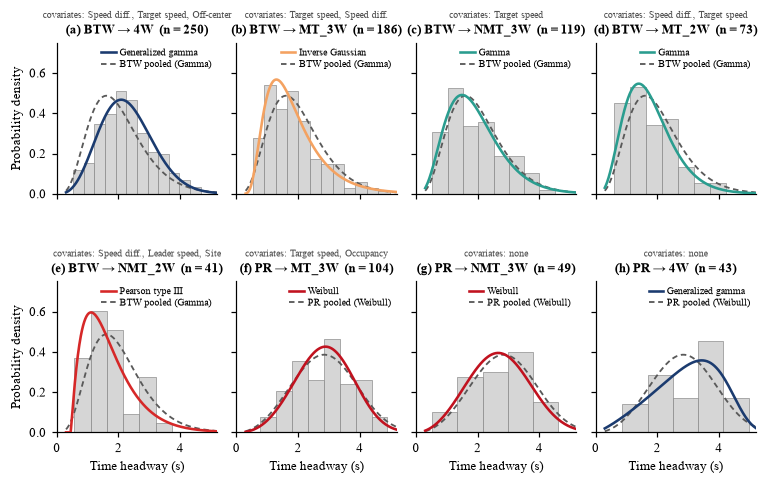


Tables -> D:\Headway\Tables 
Graphics -> D:\Headway\Graphics


In [15]:
# ============================ CELL 15 : final-model figure (pair fit vs pooled baseline) ============================
order = [p for p in INV.loc[INV.Retained].sort_values(["Target","n"], ascending=[True, False])["Pair"]
         if p in FINAL.pair.values]

# pooled (class-level) baseline: the best marginal family from the baseline stage
POOL_KEY = {"PR": "weibull_min", "BTW": "gamma"}
POOL_PAR = {cls: _fp(POOL_KEY[cls], GROUPS[cls]) for cls in ["PR", "BTW"]}

COV_SHORT = {"Target_Speed_km/hr": "Target speed", "Leading_Speed_km/hr": "Leader speed",
             "Speed_Difference": "Speed diff.", "Flow_pcu/hr/m": "Flow",
             "Off_centeredness": "Off-center", "Occupancy": "Occupancy", "Site": "Site"}
def _short_covs(s):
    if s == "(none)": return "none"
    return ", ".join(COV_SHORT.get(c.strip(), c.strip()) for c in s.split(","))

grid = np.linspace(0.3, 5.2, 400)
ncol = 4; nrow = int(np.ceil(len(order) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(8.2, 2.30 * nrow), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

ymax = 0.0
for p in order:
    x = df.loc[df.Pair == p, TH].values
    b = np.histogram_bin_edges(x, bins="fd"); b = np.linspace(x.min(), x.max(), 26) if len(b) > 30 else b
    h, _ = np.histogram(x, bins=b, density=True); ymax = max(ymax, h.max())
ymax = min(ymax * 1.32, 0.75)

for i, p in enumerate(order):
    ax = axes.ravel()[i]; r = FINAL[FINAL.pair == p].iloc[0]
    cls = p.split("_following_")[0]; key = r["dist"]; d = DISTS[key][1]
    x = df.loc[df.Pair == p, TH].values
    b = np.histogram_bin_edges(x, bins="fd"); b = np.linspace(x.min(), x.max(), 26) if len(b) > 30 else b
    ax.hist(x, bins=b, density=True, color="0.84", edgecolor="0.50", lw=0.4, zorder=1)

    ax.plot(grid, d.pdf(grid, *_fp(key, x)), color=CLR[key], lw=1.7, zorder=3,
            label=r["dist_label"])                                    # pair-specific final family
    pk = POOL_KEY[cls]
    ax.plot(grid, DISTS[pk][1].pdf(grid, *POOL_PAR[cls]), color="0.35", ls=(0, (3, 2)),
            lw=1.2, zorder=2, label=f"{cls} pooled ({DISTS[pk][0]})")  # baseline reference

    ax.set_title(f"({chr(97+i)}) {p.replace('_following_', ' \u2192 ')}  (n = {len(x)})",
                 fontsize=8.5, fontweight="bold")
    ax.text(0.5, 1.15, "covariates: " + _short_covs(r["covariates"]),
            transform=ax.transAxes, ha="center", va="bottom", fontsize=6.6, color="0.30")
    ax.legend(frameon=False, loc="upper right", fontsize=6.3,
              handlelength=1.5, labelspacing=0.25, handletextpad=0.4, borderaxespad=0.2)
    ax.set_xlim(0, 5.2); ax.set_ylim(0, ymax); ax.yaxis.set_major_locator(MaxNLocator(4))
    if i % ncol == 0: ax.set_ylabel("Probability density", fontsize=8.5)
    else:             ax.set_ylabel("")
    if i >= len(order) - ncol: ax.set_xlabel("Time headway (s)", fontsize=8.5)

for j in range(len(order), nrow * ncol):
    axes.ravel()[j].axis("off")
fig.subplots_adjust(hspace=0.58, wspace=0.12)
savefig(fig, "F7_Final_pairwise_models"); plt.show()

print("\nTables ->", TABLES, "\nGraphics ->", GRAPHS)

wrote: D:\Headway\Tables\T6_Baseline_vs_Final_Comparison.xlsx
  saved: F8_Baseline_vs_Final (.png / .pdf)


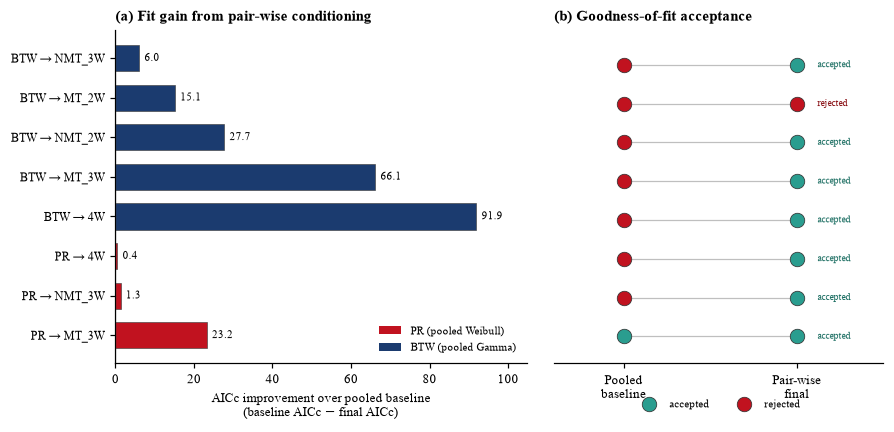


Tables -> D:\Headway\Tables 
Graphics -> D:\Headway\Graphics


In [16]:
# ============================ CELL 16 : baseline (pooled-class) vs final pair-wise model — comparison + figure ============================
from matplotlib.patches import Patch

# ---- frozen pooled-class baselines: single distribution fitted on ALL following of the class ----
BASE_KEY = {"PR": "weibull_min", "BTW": "gamma"}
BASE_LAB = {"PR": "Weibull",     "BTW": "Gamma"}
BASE_PAR = {c: _fp(BASE_KEY[c], GROUPS[c]) for c in ["PR", "BTW"]}      # held fixed, not refit per pair

def _ad_stat(d, x, par):
    xs = np.sort(x); n = len(xs)
    F = np.clip(d.cdf(xs, *par), 1e-12, 1 - 1e-12); i = np.arange(1, n + 1)
    return -n - np.sum((2 * i - 1) * (np.log(F) + np.log(1 - F[::-1]))) / n

rows = []
for _, r in FINAL.iterrows():
    cls = r["Target"]; pair = r["pair"]
    x = df.loc[df.Pair == pair, TH].values; n = len(x)
    key = BASE_KEY[cls]; d = DISTS[key][1]; par = BASE_PAR[cls]
    ll = float(np.sum(d.logpdf(x, *par)))
    base_aicc = _aicc(ll, 2, n)                                          # k=2 (class params), comparable AICc
    base_ks_p = float(stats.kstest(x, d.name, args=par).pvalue)
    base_ad   = _ad_stat(d, x, par)
    base_acc  = (base_ks_p >= 0.05) and (base_ad < 0.752)               # 5% AD crit (approx); replace w/ bootstrap for final
    rows.append(dict(
        pair=pair, label=f"{cls} \u2192 {r['Leader']}", cls=cls, n=n,
        base_dist=BASE_LAB[cls], base_AICc=base_aicc, base_KS_p=base_ks_p,
        base_AD=base_ad, base_accepted=base_acc,
        final_dist=r["dist_label"], final_AICc=r["AICc"],
        final_KS_p=r["KS_p" if "KS_p" in r else "KS p"] if False else r.get("KS_p", r.get("KS p")),
        final_AD_p=r.get("AD_p", r.get("AD p")), final_accepted=bool(r["accepted"]),
        gain_AICc=base_aicc - r["AICc"]))
CMP = pd.DataFrame(rows)

CMP_OUT = CMP[["label", "n", "base_dist", "base_AICc", "base_KS_p", "base_AD", "base_accepted",
               "final_dist", "final_AICc", "final_accepted", "gain_AICc"]].copy()
xlsx6 = os.path.join(TABLES, "T6_Baseline_vs_Final_Comparison.xlsx")
with pd.ExcelWriter(xlsx6, engine="openpyxl") as xw:
    CMP_OUT.round(4).to_excel(xw, sheet_name="Baseline_vs_final", index=False)
wb = load_workbook(xlsx6); hdr = Font(bold=True, color="FFFFFF"); fill = PatternFill("solid", fgColor="1B3B6F")
for ws in wb.worksheets:
    ws.freeze_panes = "A2"; ws.row_dimensions[1].height = 28
    for c in ws[1]:
        c.font = hdr; c.fill = fill
        c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    for col in ws.columns:
        L = max((len(str(c.value)) for c in col if c.value is not None), default=8)
        ws.column_dimensions[col[0].column_letter].width = min(max(10, L + 2), 34)
wb.save(xlsx6); print("wrote:", xlsx6)

# ---- figure: (a) AICc gain bars, (b) acceptance flip ----
C = CMP.sort_values(["cls", "gain_AICc"]).reset_index(drop=True)
col = np.where(C.cls == "PR", "#c1121f", "#1b3b6f")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.2, 4.0),
                               gridspec_kw=dict(width_ratios=[1.25, 1]))
y = np.arange(len(C))
ax1.barh(y, C.gain_AICc, color=col, edgecolor="0.25", lw=0.4, height=0.66)
ax1.set_yticks(y); ax1.set_yticklabels(C.label, fontsize=8); ax1.invert_yaxis()
ax1.axvline(0, color="0.5", lw=0.8)
ax1.set_xlabel("AICc improvement over pooled baseline\n(baseline AICc $-$ final AICc)", fontsize=8.5)
for i, v in enumerate(C.gain_AICc):
    ax1.text(v + C.gain_AICc.max()*0.015, i, f"{v:.1f}", va="center", fontsize=7.2)
ax1.set_xlim(0, C.gain_AICc.max() * 1.14)
ax1.set_title("(a) Fit gain from pair-wise conditioning", loc="left", fontweight="bold", fontsize=9.5)
ax1.legend(handles=[Patch(fc="#c1121f", label="PR (pooled Weibull)"),
                    Patch(fc="#1b3b6f", label="BTW (pooled Gamma)")],
           frameon=False, fontsize=7.5, loc="lower right")

ax2.set_xlim(-0.4, 1.5); ax2.set_ylim(-0.9, len(C) - 0.3)
ax2.set_xticks([0, 1]); ax2.set_xticklabels(["Pooled\nbaseline", "Pair-wise\nfinal"], fontsize=8.5)
ax2.invert_yaxis(); ax2.set_yticks([])
for i, (_, r) in enumerate(C.iterrows()):
    c0 = "#2a9d8f" if r.base_accepted  else "#c1121f"
    c1 = "#2a9d8f" if r.final_accepted else "#c1121f"
    ax2.plot([0, 1], [i, i], color="0.75", lw=0.8, zorder=1)
    ax2.scatter([0], [i], s=90, color=c0, zorder=3, edgecolor="0.2", lw=0.5)
    ax2.scatter([1], [i], s=90, color=c1, zorder=3, edgecolor="0.2", lw=0.5)
    ax2.text(1.12, i, "accepted" if r.final_accepted else "rejected", va="center",
             fontsize=6.8, color="#1d6f63" if r.final_accepted else "#8a1116")
ax2.set_title("(b) Goodness-of-fit acceptance", loc="left", fontweight="bold", fontsize=9.5)
ax2.scatter([], [], s=90, color="#2a9d8f", edgecolor="0.2", lw=0.5, label="accepted")
ax2.scatter([], [], s=90, color="#c1121f", edgecolor="0.2", lw=0.5, label="rejected")
ax2.legend(frameon=False, fontsize=7.5, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.17))
ax2.spines["left"].set_visible(False)
fig.tight_layout(w_pad=2.0)
savefig(fig, "F8_Baseline_vs_Final"); plt.show()
print("\nTables ->", TABLES, "\nGraphics ->", GRAPHS)

In [17]:
# ============================ CELL 17 : Spearman correlations for discussion (per-pair) ============================
from scipy import stats

TS   = "Target_Speed_km/hr"
SD   = "Speed_Difference"
OCC  = "Occupancy"
OFF  = "Off_centeredness"

# coerce the two boolean covariates to 0/1 for correlation
dfx = df.copy()
for c in [OCC, OFF]:
    if dfx[c].dtype == bool:
        dfx[c] = dfx[c].astype(int)

PRETTY = {TS: "Target speed", SD: "Speed difference", OCC: "Occupancy",
          OFF: "Off-centeredness", TH: "Time headway"}

# ---- (pair, var1, var2) requests ----
REQ = [
    ("PR_following_NMT_3W",  OCC, TS),
    ("PR_following_NMT_3W",  OCC, TH),
    ("PR_following_NMT_3W",  TS,  TH),
    ("BTW_following_NMT_2W", TH,  TS),
    ("BTW_following_NMT_2W", TH,  SD),
    ("BTW_following_NMT_3W", TH,  TS),
    ("BTW_following_NMT_3W", TH,  SD),
    ("BTW_following_MT_2W",  TH,  TS),
    ("BTW_following_MT_2W",  TH,  SD),
    ("BTW_following_MT_3W",  TH,  TS),
    ("BTW_following_MT_3W",  TH,  SD),
    ("BTW_following_4W",     TH,  TS),
    ("BTW_following_4W",     TH,  SD),
    ("BTW_following_4W",     OFF, SD),
]

rows = []
for pair, a, b in REQ:
    sub = dfx.loc[dfx.Pair == pair, [a, b]].dropna()
    n = len(sub)
    binflag = (a in (OCC, OFF)) or (b in (OCC, OFF))
    if sub[a].nunique() < 2 or sub[b].nunique() < 2:
        rho = pv = np.nan
    else:
        rho, pv = stats.spearmanr(sub[a], sub[b])
    rows.append(dict(
        Pair=pair.replace("_following_", " \u2192 "),
        Variable_1=PRETTY[a], Variable_2=PRETTY[b], n=n,
        Spearman_rho=rho, p_value=pv,
        Strength=("—" if not np.isfinite(rho) else
                  "negligible" if abs(rho) < 0.10 else
                  "weak"       if abs(rho) < 0.30 else
                  "moderate"   if abs(rho) < 0.50 else "strong"),
        Sig=("" if not np.isfinite(pv) else "***" if pv < 0.001 else
             "**" if pv < 0.01 else "*" if pv < 0.05 else "ns"),
        Note=("point-biserial (binary var)" if binflag else "")))
CORR = pd.DataFrame(rows)

# ---- export ----
xlsx7 = os.path.join(TABLES, "T7_Spearman_Correlations.xlsx")
with pd.ExcelWriter(xlsx7, engine="openpyxl") as xw:
    CORR.round(4).to_excel(xw, sheet_name="Spearman", index=False)
wb = load_workbook(xlsx7); hdr = Font(bold=True, color="FFFFFF"); fill = PatternFill("solid", fgColor="1B3B6F")
for ws in wb.worksheets:
    ws.freeze_panes = "A2"; ws.row_dimensions[1].height = 28
    for c in ws[1]:
        c.font = hdr; c.fill = fill
        c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    for col in ws.columns:
        L = max((len(str(c.value)) for c in col if c.value is not None), default=8)
        ws.column_dimensions[col[0].column_letter].width = min(max(10, L + 2), 30)
wb.save(xlsx7)
print(CORR.round(3).to_string(index=False))
print("\nwrote:", xlsx7)

        Pair       Variable_1       Variable_2   n  Spearman_rho  p_value   Strength Sig                        Note
 PR → NMT_3W        Occupancy     Target speed  49        -0.182    0.210       weak  ns point-biserial (binary var)
 PR → NMT_3W        Occupancy     Time headway  49         0.003    0.984 negligible  ns point-biserial (binary var)
 PR → NMT_3W     Target speed     Time headway  49         0.016    0.913 negligible  ns                            
BTW → NMT_2W     Time headway     Target speed  41        -0.179    0.262       weak  ns                            
BTW → NMT_2W     Time headway Speed difference  41        -0.445    0.004   moderate  **                            
BTW → NMT_3W     Time headway     Target speed 119        -0.245    0.007       weak  **                            
BTW → NMT_3W     Time headway Speed difference 119        -0.067    0.466 negligible  ns                            
 BTW → MT_2W     Time headway     Target speed  73        -0.269

  saved: F9_Spearman_lollipop (.png / .pdf)


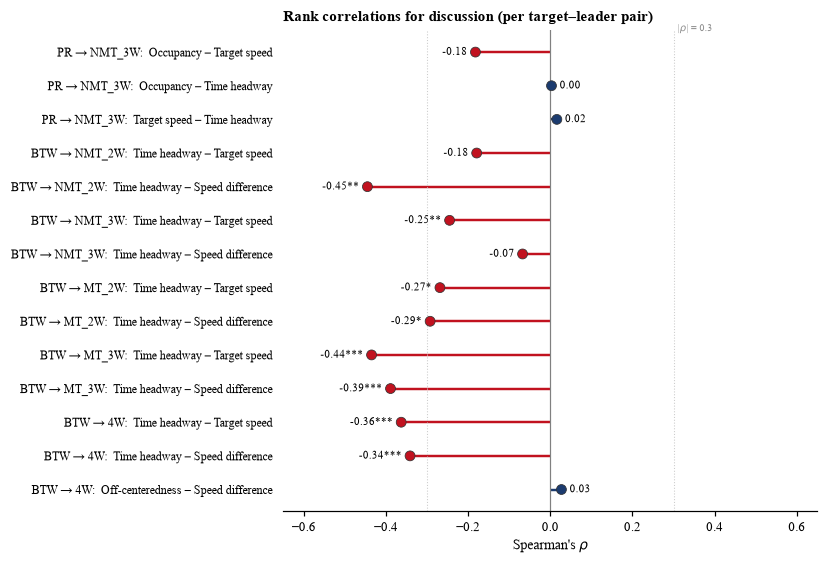

  saved: F10_Correlation_scatter (.png / .pdf)


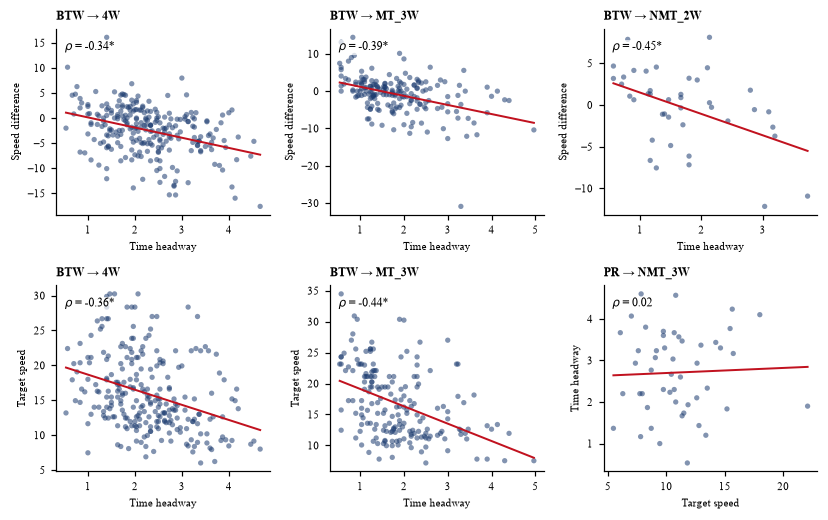


Tables -> D:\Headway\Tables 
Graphics -> D:\Headway\Graphics


In [18]:
# ============================ CELL 18 : correlation figures ============================
# ---- Figure A: lollipop of Spearman rho, grouped, significance-marked ----
C = CORR.copy()
C["label"] = C["Pair"] + ":  " + C["Variable_1"] + " \u2013 " + C["Variable_2"]
C = C.iloc[::-1].reset_index(drop=True)                      # top-to-bottom in request order
col = np.where(C.Spearman_rho >= 0, "#1b3b6f", "#c1121f")

fig, ax = plt.subplots(figsize=(7.6, 5.2))
y = np.arange(len(C))
ax.hlines(y, 0, C.Spearman_rho, color=col, lw=1.6, zorder=2)
ax.scatter(C.Spearman_rho, y, color=col, s=42, zorder=3, edgecolor="0.2", lw=0.5)
ax.axvline(0, color="0.5", lw=0.8)
for thr in (-0.3, 0.3):
    ax.axvline(thr, color="0.8", lw=0.7, ls=":")
for i, r in C.iterrows():
    if np.isfinite(r.Spearman_rho):
        off = 0.02 if r.Spearman_rho >= 0 else -0.02
        ax.text(r.Spearman_rho + off, i, f"{r.Spearman_rho:.2f}{'' if r.Sig=='ns' else r.Sig}",
                va="center", ha="left" if r.Spearman_rho >= 0 else "right", fontsize=7.2)
ax.set_yticks(y); ax.set_yticklabels(C.label, fontsize=7.6)
ax.set_xlim(-0.65, 0.65)
ax.set_xlabel("Spearman's $\\rho$", fontsize=9)
ax.set_title("Rank correlations for discussion (per target\u2013leader pair)",
             loc="left", fontweight="bold", fontsize=10)
ax.text(0.31, len(C)-0.4, "|$\\rho$| = 0.3", fontsize=6.8, color="0.55")
ax.spines["left"].set_visible(False); ax.tick_params(left=False)
fig.tight_layout(); savefig(fig, "F9_Spearman_lollipop"); plt.show()

# ---- Figure B: scatter matrix for the key BTW speed relationships + PR occupancy triad ----
SCAT = [
    ("BTW_following_4W",     TH,  SD,  "BTW \u2192 4W"),
    ("BTW_following_MT_3W",  TH,  SD,  "BTW \u2192 MT_3W"),
    ("BTW_following_NMT_2W", TH,  SD,  "BTW \u2192 NMT_2W"),
    ("BTW_following_4W",     TH,  TS,  "BTW \u2192 4W"),
    ("BTW_following_MT_3W",  TH,  TS,  "BTW \u2192 MT_3W"),
    ("PR_following_NMT_3W",  TS,  TH,  "PR \u2192 NMT_3W"),
]
fig, axes = plt.subplots(2, 3, figsize=(7.6, 4.8))
for ax, (pair, a, b, title) in zip(axes.ravel(), SCAT):
    sub = dfx.loc[dfx.Pair == pair, [a, b]].dropna()
    ax.scatter(sub[a], sub[b], s=12, color="#1b3b6f", alpha=0.55, edgecolor="none")
    if sub[a].nunique() > 1 and sub[b].nunique() > 1:
        rho, pv = stats.spearmanr(sub[a], sub[b])
        # monotone trend guide via rank-based lowess-free linear on ranks -> back to raw for display
        z = np.polyfit(sub[a], sub[b], 1); xx = np.linspace(sub[a].min(), sub[a].max(), 50)
        ax.plot(xx, np.polyval(z, xx), color="#c1121f", lw=1.3)
        ax.text(0.04, 0.93, f"$\\rho$ = {rho:.2f}{'' if pv>=0.05 else '*'}",
                transform=ax.transAxes, fontsize=7.6, va="top",
                bbox=dict(fc="white", ec="none", alpha=0.7, pad=1))
    ax.set_title(title, fontsize=8, fontweight="bold", loc="left")
    ax.set_xlabel(PRETTY[a], fontsize=7.5); ax.set_ylabel(PRETTY[b], fontsize=7.5)
    ax.tick_params(labelsize=7)
fig.tight_layout(); savefig(fig, "F10_Correlation_scatter"); plt.show()

print("\nTables ->", TABLES, "\nGraphics ->", GRAPHS)

In [19]:
# ============================ CELL 17 : Spearman correlations for discussion (per-pair) ============================
from scipy import stats

TS  = "Target_Speed_km/hr"; SD = "Speed_Difference"
OCC = "Occupancy";          OFF = "Off_centeredness"

dfx = df.copy()
for c in [OCC, OFF]:
    if dfx[c].dtype == bool: dfx[c] = dfx[c].astype(int)

PRETTY = {TS: "Target speed", SD: "Speed difference", OCC: "Occupancy",
          OFF: "Off-centeredness", TH: "Time headway"}

REQ = [
    ("PR_following_NMT_3W",  OCC, TS), ("PR_following_NMT_3W",  OCC, TH), ("PR_following_NMT_3W",  TS, TH),
    ("PR_following_MT_3W",   OCC, TS), ("PR_following_MT_3W",   OCC, TH), ("PR_following_MT_3W",   TS, TH),
    ("BTW_following_NMT_2W", TH,  TS), ("BTW_following_NMT_2W", TH,  SD),
    ("BTW_following_NMT_3W", TH,  TS), ("BTW_following_NMT_3W", TH,  SD),
    ("BTW_following_MT_2W",  TH,  TS), ("BTW_following_MT_2W",  TH,  SD),
    ("BTW_following_MT_3W",  TH,  TS), ("BTW_following_MT_3W",  TH,  SD),
    ("BTW_following_4W",     TH,  TS), ("BTW_following_4W",     TH,  SD), ("BTW_following_4W", OFF, SD),
]

rows = []
for pair, a, b in REQ:
    sub = dfx.loc[dfx.Pair == pair, [a, b]].dropna(); n = len(sub)
    binflag = (a in (OCC, OFF)) or (b in (OCC, OFF))
    if sub[a].nunique() < 2 or sub[b].nunique() < 2:
        rho = pv = np.nan
    else:
        rho, pv = stats.spearmanr(sub[a], sub[b])
    rows.append(dict(
        Pair=pair.replace("_following_", " \u2192 "), Variable_1=PRETTY[a], Variable_2=PRETTY[b], n=n,
        Spearman_rho=rho, p_value=pv,
        Strength=("\u2014" if not np.isfinite(rho) else
                  "negligible" if abs(rho) < 0.10 else "weak" if abs(rho) < 0.30 else
                  "moderate" if abs(rho) < 0.50 else "strong"),
        Sig=("" if not np.isfinite(pv) else "***" if pv < 0.001 else
             "**" if pv < 0.01 else "*" if pv < 0.05 else "ns"),
        Note=("point-biserial (binary var)" if binflag else "")))
CORR = pd.DataFrame(rows)

xlsx7 = os.path.join(TABLES, "T7_Spearman_Correlations.xlsx")
with pd.ExcelWriter(xlsx7, engine="openpyxl") as xw:
    CORR.round(4).to_excel(xw, sheet_name="Spearman", index=False)
wb = load_workbook(xlsx7); hdr = Font(bold=True, color="FFFFFF"); fill = PatternFill("solid", fgColor="1B3B6F")
for ws in wb.worksheets:
    ws.freeze_panes = "A2"; ws.row_dimensions[1].height = 28
    for c in ws[1]:
        c.font = hdr; c.fill = fill
        c.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    for col in ws.columns:
        L = max((len(str(c.value)) for c in col if c.value is not None), default=8)
        ws.column_dimensions[col[0].column_letter].width = min(max(10, L + 2), 30)
wb.save(xlsx7)
print(CORR.round(4).to_string(index=False)); print("\nwrote:", xlsx7)

        Pair       Variable_1       Variable_2   n  Spearman_rho  p_value   Strength Sig                        Note
 PR → NMT_3W        Occupancy     Target speed  49       -0.1822   0.2103       weak  ns point-biserial (binary var)
 PR → NMT_3W        Occupancy     Time headway  49        0.0030   0.9839 negligible  ns point-biserial (binary var)
 PR → NMT_3W     Target speed     Time headway  49        0.0160   0.9130 negligible  ns                            
  PR → MT_3W        Occupancy     Target speed 104        0.2370   0.0154       weak   * point-biserial (binary var)
  PR → MT_3W        Occupancy     Time headway 104       -0.3264   0.0007   moderate *** point-biserial (binary var)
  PR → MT_3W     Target speed     Time headway 104       -0.5029   0.0000     strong ***                            
BTW → NMT_2W     Time headway     Target speed  41       -0.1791   0.2624       weak  ns                            
BTW → NMT_2W     Time headway Speed difference  41       -0.4451